# Bachelorarbeit – Evaluation von Deep-Learning-Modellen zur Brustkrebsklassifikation in der Screening-Mammographie
**Edanur Gür | MCI Innsbruck | RSNA Screening Mammography Dataset**

## Struktur
1. Imports & Konfiguration
2. Hilfsfunktionen (Preprocessing)
3. Daten laden, Datei-Check & Balancierung
4. Dataset & DataLoader
5. Modell A – Einfaches CNN von Null
6. Modell B – Transfer Learning mit Fine-Tuning (ResNet18)
7. Training & Validierung
8. Evaluation (ROC, Confusion Matrix, AUC)
9. Metadaten-Analyse A – Performance nach Altersgruppe
10. Metadaten-Analyse B – Alter als zusätzlicher Modell-Input (Multimodal)
11. Metadaten-Analyse C – BIRADS & Brustdichte
12. PCA Visualisierung
13. Architektur-Vergleich
14. Systematische Untersuchungen (E0 Overfit-Test, E2 alle Daten + pos_weight)
15. Ergebnisdokumentation speichern
16. E5 - Seed-Robustheit und Konfidenzintervall
17. E1 - Auflösung 512 px
18. Weitere Untersuchungen (E4 Lernrate, E3 Auftau-Tiefe, E6 Split-Vergleich)
19. E3 Absicherung (Seed-Robustheit der Auftau-Tiefe)
20. E7 - Lernkurve (Performance vs. Trainingsdatenmenge)
21. Finales Modell - konkrete Tumor Ja/Nein Klassifikation
22. Grad-CAM - wo im Bild schaut das Modell hin?
23. Test-Set-Evaluation - ehrliche Endbewertung (70/15/15)


## 1. Imports & Konfiguration

In [1]:
import os
import time
import numpy as np
import pandas as pd
import cv2
import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Konfiguration
BILD_GROESSE  = 384
BATCH_SIZE    = 16
EPOCHEN       = 15
LERNRATE      = 1e-3
VAL_ANTEIL    = 0.2        # 20% Validierung, 80% Training
ZUFALLSZAHL   = 42         # Für Reproduzierbarkeit
BILDER_ORDNER = 'train_images'
CSV_PFAD      = 'train.csv'
MODELL_PFAD_A = 'modell_cnn_scratch.pth'
MODELL_PFAD_B = 'modell_resnet18.pth'
MODELL_PFAD_C = 'modell_resnet18_multimodal.pth'

torch.manual_seed(ZUFALLSZAHL)
np.random.seed(ZUFALLSZAHL)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Gerät: {DEVICE.type.upper()}')

Gerät: CUDA


## 2. Hilfsfunktionen (Preprocessing)

Testbild: train_images/10086/1973073874.dcm


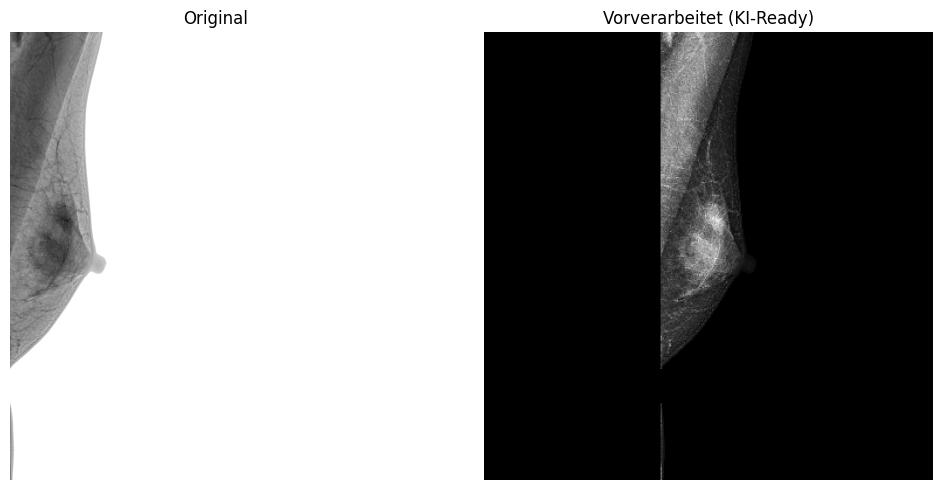

In [2]:
def lade_und_verarbeite_dicom(bild_pfad: str, zielgroesse: int = BILD_GROESSE) -> np.ndarray:
    """
    Lädt eine DICOM-Datei und gibt ein vorverarbeitetes uint8-Array zurück.
    Schritte: VOI-LUT (radiologisches Fenster) -> Invertierung bei MONOCHROME1
    -> Normalisierung auf [0,255] -> schwarzen Rand wegschneiden
    -> auf Quadrat auffüllen (Seitenverhältnis bleibt erhalten) -> Resize.
    """
    dicom = pydicom.dcmread(bild_pfad)
    # VOI-LUT
    bild  = apply_voi_lut(dicom.pixel_array, dicom).astype(np.float32)

    # Invertieren wenn Hintergrund hell ist (MONOCHROME1)
    if getattr(dicom, 'PhotometricInterpretation', '') == 'MONOCHROME1':
        bild = bild.max() - bild

    # Normalisierung auf [0, 255]
    bild_min, bild_max = bild.min(), bild.max()
    if bild_max > bild_min:
        bild = (bild - bild_min) / (bild_max - bild_min)
    bild = (bild * 255).astype(np.uint8)

    # Schwarze Ränder wegschneiden
    maske = bild > 15
    if maske.any():
        zeilen  = np.where(maske.any(axis=1))[0]
        spalten = np.where(maske.any(axis=0))[0]
        bild = bild[zeilen[0]:zeilen[-1]+1, spalten[0]:spalten[-1]+1]

    # Auf Quadrat auffüllen (schwarze Ränder), damit das Seitenverhältnis
    # erhalten bleibt und der Brustbereich nicht horizontal verzerrt wird
    h, w = bild.shape
    seite = max(h, w)
    quadrat = np.zeros((seite, seite), dtype=bild.dtype)
    quadrat[(seite - h) // 2:(seite - h) // 2 + h, (seite - w) // 2:(seite - w) // 2 + w] = bild
    bild = quadrat

    bild = cv2.resize(bild, (zielgroesse, zielgroesse))
    return bild


def zeige_vorher_nachher(bild_pfad: str):
    """Zeigt Original und vorverarbeitetes Bild nebeneinander."""
    original    = pydicom.dcmread(bild_pfad).pixel_array
    verarbeitet = lade_und_verarbeite_dicom(bild_pfad)
    fig, achsen = plt.subplots(1, 2, figsize=(10, 5))
    achsen[0].imshow(original,    cmap='gray'); achsen[0].set_title('Original');            achsen[0].axis('off')
    achsen[1].imshow(verarbeitet, cmap='gray'); achsen[1].set_title('Vorverarbeitet (KI-Ready)'); achsen[1].axis('off')
    plt.tight_layout(); plt.show()


# Kurzer Test: erstes verfügbares DICOM automatisch finden
test_pfad = None
if os.path.isdir(BILDER_ORDNER):
    for patient_ordner in sorted(os.listdir(BILDER_ORDNER)):
        patient_pfad = os.path.join(BILDER_ORDNER, patient_ordner)
        if os.path.isdir(patient_pfad):
            for bild_datei in os.listdir(patient_pfad):
                if bild_datei.endswith('.dcm'):
                    test_pfad = os.path.join(BILDER_ORDNER, patient_ordner, bild_datei).replace('\\', '/')
                    break
        if test_pfad:
            break

if test_pfad and os.path.exists(test_pfad):
    print(f'Testbild: {test_pfad}')
    zeige_vorher_nachher(test_pfad)
else:
    print('Kein Testbild gefunden – bitte train_images/ prüfen')

## 3. Daten laden, Datei-Check & Balancierung

In [3]:
# CSV laden
df_roh = pd.read_csv(CSV_PFAD)
print(f'Einträge in CSV gesamt: {len(df_roh):,}')
print(f'Gesund (0): {(df_roh["cancer"]==0).sum():,}  |  Krebs (1): {(df_roh["cancer"]==1).sum():,}')
display(df_roh.head())

print('\nPrüfe welche Bilddateien vorhanden sind...')

def bild_pfad_existiert(zeile):
    pfad = f"{BILDER_ORDNER}/{zeile['patient_id']}/{zeile['image_id']}.dcm"
    return os.path.exists(pfad)

df_roh['datei_vorhanden'] = df_roh.apply(bild_pfad_existiert, axis=1)
df_verfuegbar = df_roh[df_roh['datei_vorhanden']].copy().reset_index(drop=True)

print(f'Bilder gefunden:     {len(df_verfuegbar):,}')
print(f'Bilder nicht gefunden: {(~df_roh["datei_vorhanden"]).sum():,}')
print(f'\nVerfügbar – Gesund: {(df_verfuegbar["cancer"]==0).sum():,}  |  Krebs: {(df_verfuegbar["cancer"]==1).sum():,}')

Einträge in CSV gesamt: 54,706
Gesund (0): 53,548  |  Krebs (1): 1,158


,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
0,2,10006,462822612,L,CC,61.0,0,0,0,NaN,0,NaN,29,False
1,2,10006,1459541791,L,MLO,61.0,0,0,0,NaN,0,NaN,29,False
2,2,10006,1864590858,R,MLO,61.0,0,0,0,NaN,0,NaN,29,False
3,2,10006,1874946579,R,CC,61.0,0,0,0,NaN,0,NaN,29,False
4,2,10011,220375232,L,CC,55.0,0,0,0,0.0,0,NaN,21,True



Prüfe welche Bilddateien vorhanden sind...
Bilder gefunden:     2,316
Bilder nicht gefunden: 52,390

Verfügbar – Gesund: 1,158  |  Krebs: 1,158


Krebs-Fälle:  1,158
Gesund-Fälle: 1,158

Balancierter Datensatz: 2,316 Bilder (50% Krebs / 50% Gesund)


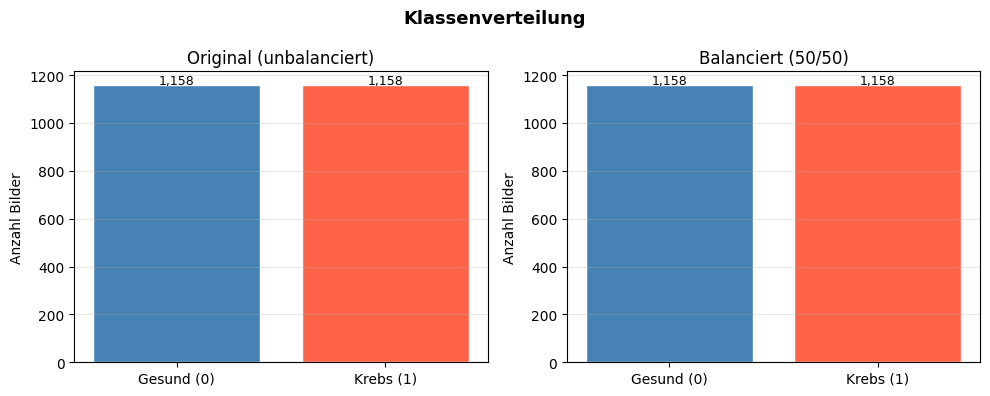

In [4]:
# Balancierung
# Ursprünglich sollte hier auf 50/50 undersampelt werden, damit das Modell beide
# Klassen gleich gut lernt. Nach der Datensatz-Erweiterung ist der Bestand aber
# bereits exakt balanciert (1158 Krebs / 1158 gesund), deshalb zieht sample() alle
# Gesund-Bilder und es wird KEIN einziges Bild verworfen. Der Schritt bleibt drin,
# damit der Code auch mit einem unbalancierten Datensatz korrekt funktioniert.

krebs_df  = df_verfuegbar[df_verfuegbar['cancer'] == 1]
gesund_df = df_verfuegbar[df_verfuegbar['cancer'] == 0]
n_krebs   = len(krebs_df)

print(f'Krebs-Fälle:  {n_krebs:,}')
print(f'Gesund-Fälle: {len(gesund_df):,}')

# 50/50 balanciert
gesund_sampled = gesund_df.sample(n=n_krebs, random_state=ZUFALLSZAHL)
df = pd.concat([krebs_df, gesund_sampled]).sample(
    frac=1, random_state=ZUFALLSZAHL).reset_index(drop=True)

print(f'\nBalancierter Datensatz: {len(df):,} Bilder (50% Krebs / 50% Gesund)')

# Visualisierung Vorher / Nachher
fig, achsen = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Klassenverteilung', fontsize=13, fontweight='bold')

for ax, daten, titel in zip(
    achsen,
    [df_verfuegbar, df],
    ['Original (unbalanciert)', 'Balanciert (50/50)']
):
    werte  = daten['cancer'].value_counts().sort_index()
    farben = ['steelblue', 'tomato']
    ax.bar(['Gesund (0)', 'Krebs (1)'], werte.values, color=farben, edgecolor='white')
    ax.set_title(titel)
    ax.set_ylabel('Anzahl Bilder')
    for i, v in enumerate(werte.values):
        ax.text(i, v + 5, f'{v:,}', ha='center', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Altersgruppen für spätere Metadaten-Analyse vorbereiten
df['altersgruppe'] = pd.cut(
    df['age'],
    bins=[0, 40, 50, 60, 70, 120],
    labels=['<40', '40-50', '50-60', '60-70', '>70']
)

## 4. Dataset & DataLoader

In [5]:
# transforms
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transforms_1kanal = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
val_transforms_1kanal = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
train_transforms_3kanal = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])
val_transforms_3kanal = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])


# Bilder verarbeiten & auf Platte cachen --> Disk-Cache

import pickle
cache_datei = f'bild_cache_{BILD_GROESSE}.pkl'

if os.path.exists(cache_datei):
    print(f'Lade Bilder aus Disk-Cache ({cache_datei})...', flush=True)
    with open(cache_datei, 'rb') as f:
        bild_cache = pickle.load(f)
    print(f'Disk-Cache geladen: {len(bild_cache)} Bilder im RAM', flush=True)
else:
    print('Erster Lauf: verarbeite alle verfügbaren DICOMs (einmalig länger)...', flush=True)
    bild_cache = {}
    for idx, zeile in df_verfuegbar.iterrows():
        pfad = f"{BILDER_ORDNER}/{zeile['patient_id']}/{zeile['image_id']}.dcm"
        bild_cache[pfad] = lade_und_verarbeite_dicom(pfad)
        if (len(bild_cache)) % 50 == 0:
            print(f'  {len(bild_cache)}/{len(df_verfuegbar)} Bilder verarbeitet...', flush=True)
    with open(cache_datei, 'wb') as f:
        pickle.dump(bild_cache, f)
    print(f'Cache fertig: {len(bild_cache)} Bilder, gespeichert in {cache_datei}.', flush=True)
    print('Ab jetzt lädt jeder Kernel-Neustart in wenigen Sekunden.', flush=True)


class MammografieDataset(Dataset):
    """Liefert die vorverarbeiteten Bilder aus dem Cache an PyTorch.
    Je nach Bedarf als 1-Kanal (CNN) oder 3-Kanal (ResNet), optional
    zusätzlich mit dem normalisierten Alter als Eingabe."""
    def __init__(self, dataframe, basis_ordner,
                 transform=None, fuer_resnet18=False, mit_alter=False,
                 alter_mean=None, alter_std=None):
        self.df            = dataframe.reset_index(drop=True)
        self.basis_ordner  = basis_ordner
        self.transform     = transform
        self.fuer_resnet18 = fuer_resnet18
        self.mit_alter     = mit_alter
        # Alters-Normalisierung: mean/std werden idealerweise NUR aus den
        # Trainingsdaten übergeben (siehe erstelle_dataloaders). So sieht das
        # Validierungsset keine eigenen Statistiken -> kein Data Leakage.
        # Fallback (mean/std None): aus dem eigenen DataFrame, damit die Klasse
        # auch einzeln (z.B. für PCA) weiter funktioniert.
        self.alter_mean    = alter_mean if alter_mean is not None else self.df['age'].mean()
        self.alter_std     = alter_std  if alter_std  is not None else (self.df['age'].std() + 1e-8)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        zeile     = self.df.iloc[idx]
        bild_pfad = f"{self.basis_ordner}/{zeile['patient_id']}/{zeile['image_id']}.dcm"
        label     = torch.tensor(zeile['cancer'], dtype=torch.float32)

        bild = bild_cache[bild_pfad]

        if self.fuer_resnet18:
            bild = np.stack([bild, bild, bild], axis=-1)
            bild_tensor = self.transform(bild) if self.transform else \
                torch.tensor(bild.transpose(2,0,1), dtype=torch.float32) / 255.0
        else:
            bild_tensor = self.transform(bild) if self.transform else \
                torch.tensor(bild[np.newaxis], dtype=torch.float32) / 255.0

        meta = {
            'patient_id':   zeile['patient_id'],
            'age':          zeile.get('age', -1),
            'laterality':   zeile.get('laterality', ''),
            'view':         zeile.get('view', ''),
            'altersgruppe': str(zeile.get('altersgruppe', '')),
            'BIRADS':       float(zeile['BIRADS']) if pd.notna(zeile.get('BIRADS', float('nan'))) else -1.0,
            'density':      str(zeile['density'])  if pd.notna(zeile.get('density',  float('nan'))) else 'unbekannt',
        }

        if self.mit_alter:
            alter_norm = torch.tensor(
                [(zeile.get('age', self.alter_mean) - self.alter_mean) / self.alter_std],
                dtype=torch.float32
            )
            return bild_tensor, label, alter_norm, meta

        return bild_tensor, label, meta


def erstelle_dataloaders(dataframe, fuer_resnet18=False, mit_alter=False,
                          batch_size=BATCH_SIZE):
    # Aufteilung nach patient_id statt nach einzelnem Bild.
    # Verhindert Data Leakage: ein Patient hat mehrere Aufnahmen (links/rechts, CC/MLO) die nicht gleichzeitig in Training
    # UND Validierung landen dürfen, sonst sind die Val-Werte zu optimistisch.
    """Teilt den Datensatz patientenweise in Training und Validierung auf und
    gibt beide DataLoader samt der zugehörigen DataFrames zurück."""
    patienten = dataframe['patient_id'].unique()
    rng = np.random.default_rng(ZUFALLSZAHL)
    rng.shuffle(patienten)
    n_val_pat = int(len(patienten) * VAL_ANTEIL)
    val_patienten = set(patienten[:n_val_pat])
    df_val   = dataframe[dataframe['patient_id'].isin(val_patienten)]
    df_train = dataframe[~dataframe['patient_id'].isin(val_patienten)]

    t_train = train_transforms_3kanal if fuer_resnet18 else train_transforms_1kanal
    t_val   = val_transforms_3kanal   if fuer_resnet18 else val_transforms_1kanal

    # Alters-Statistik NUR aus dem Trainingsset berechnen und an BEIDE Datasets
    # weiterreichen (kein Leakage von Val-Statistik ins Modell C).
    alter_mean = df_train['age'].mean()
    alter_std  = df_train['age'].std() + 1e-8

    ds_train = MammografieDataset(df_train, BILDER_ORDNER, t_train, fuer_resnet18, mit_alter, alter_mean, alter_std)
    ds_val   = MammografieDataset(df_val,   BILDER_ORDNER, t_val,   fuer_resnet18, mit_alter, alter_mean, alter_std)

    loader_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True,
                               num_workers=0, pin_memory=torch.cuda.is_available())
    loader_val   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False,
                               num_workers=0, pin_memory=torch.cuda.is_available())

    print(f'Train: {len(ds_train):,} | Val: {len(ds_val):,} Bilder')
    return loader_train, loader_val, df_train, df_val


loader_train_a, loader_val_a, df_train, df_val = erstelle_dataloaders(df, fuer_resnet18=False)
loader_train_b, loader_val_b, _, _             = erstelle_dataloaders(df, fuer_resnet18=True)

Lade Bilder aus Disk-Cache (bild_cache_384.pkl)...
Disk-Cache geladen: 2316 Bilder im RAM
Train: 1,835 | Val: 481 Bilder
Train: 1,835 | Val: 481 Bilder


## 5. Modell A – Einfaches CNN von Null

In [6]:
class EinfachesBrustkrebsCNN(nn.Module):
    """
    Kleines CNN als Baseline (Modell A).
    3 Conv-Schichten + AdaptiveAvgPool → funktioniert mit jeder Eingabegröße.
    Dropout gegen Overfitting.
    """
    def __init__(self, in_kanale=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_kanale, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),        nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),        nn.ReLU(), nn.MaxPool2d(2),
        )
        self.avgpool    = nn.AdaptiveAvgPool2d((8, 8))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 1), nn.Sigmoid()
        )

    def forward(self, x):
        return self.classifier(self.avgpool(self.features(x)))


modell_a = EinfachesBrustkrebsCNN(in_kanale=1).to(DEVICE)
params_a  = sum(p.numel() for p in modell_a.parameters() if p.requires_grad)
print(f'Modell A – CNN von Null: {params_a:,} trainierbare Parameter')
print(modell_a)

Modell A – CNN von Null: 1,072,385 trainierbare Parameter
EinfachesBrustkrebsCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(8, 8))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## 6. Modell B – Transfer Learning mit Fine-Tuning (ResNet18)

In [7]:
def erstelle_resnet18():
    """
    ResNet18 mit vortrainierten ImageNet-Gewichten.
    Phase 1: Nur FC-Kopf trainierbar (513 Parameter).
    Phase 2: Nur letzter Residual-Block (layer4[1]) + FC aufgetaut.
    """
    modell = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in modell.parameters():
        param.requires_grad = False
    modell.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(modell.fc.in_features, 1),
        nn.Sigmoid()
    )
    return modell.to(DEVICE)


def auftauen_fuer_finetuning(modell):
    """Phase 2: nur letzten Block von layer4 + FC auftauen.
    Statt ganz layer4 (8.394.241 trainierbare Parameter inkl. FC-Kopf) wird nur
    der letzte Block aufgetaut: 4.721.153 Parameter (layer4[1] 4.720.640 +
    FC-Kopf 513), also rund die Hälfte -> weniger Overfitting bei kleiner
    Datenmenge.
    """
    for param in modell.parameters():
        param.requires_grad = False
    for param in modell.layer4[1].parameters():   # nur letzter Block
        param.requires_grad = True
    for param in modell.fc.parameters():
        param.requires_grad = True


modell_b = erstelle_resnet18()
p_phase1 = sum(p.numel() for p in modell_b.parameters() if p.requires_grad)
auftauen_fuer_finetuning(modell_b)
p_phase2 = sum(p.numel() for p in modell_b.parameters() if p.requires_grad)
gesamt   = sum(p.numel() for p in modell_b.parameters())

print(f'Modell B – ResNet18 (Transfer Learning + Fine-Tuning)')
print(f'Phase 1 – Trainierbare Parameter: {p_phase1:>10,} (nur FC-Kopf)')
print(f'Phase 2 – Trainierbare Parameter: {p_phase2:>10,} (layer4[1] + FC)')
print(f'Gesamt  – Eingefroren in Phase 1: {gesamt-p_phase1:>10,}')

modell_b = erstelle_resnet18()

Modell B – ResNet18 (Transfer Learning + Fine-Tuning)
Phase 1 – Trainierbare Parameter:        513 (nur FC-Kopf)
Phase 2 – Trainierbare Parameter:  4,721,153 (layer4[1] + FC)
Gesamt  – Eingefroren in Phase 1: 11,176,512


## 7. Training & Validierung

In [8]:
def trainiere_eine_epoche(modell, loader, optimierer, kriterium, mit_alter=False):
    """Trainiert das Modell eine Epoche lang und gibt den mittleren
    Trainings-Loss zurück."""
    modell.train()
    gesamt_loss = 0.0
    for batch in loader:
        if mit_alter:
            bilder, labels, alter, _ = batch
            alter = alter.to(DEVICE)
        else:
            bilder, labels, _ = batch
            alter = None

        bilder = bilder.to(DEVICE)
        labels = labels.unsqueeze(1).to(DEVICE)

        optimierer.zero_grad()
        vorhersagen = modell(bilder, alter) if mit_alter else modell(bilder)
        loss        = kriterium(vorhersagen, labels)
        loss.backward()
        optimierer.step()
        gesamt_loss += loss.item()

    return gesamt_loss / len(loader)


def validiere(modell, loader, kriterium, mit_alter=False):
    """Wertet das Modell auf einem Loader aus, ohne zu trainieren.
    Gibt mittleren Loss, echte Labels und Vorhersagen zurück."""
    modell.eval()
    gesamt_loss = 0.0
    alle_labels, alle_preds = [], []

    with torch.no_grad():
        for batch in loader:
            if mit_alter:
                bilder, labels, alter, _ = batch
                alter = alter.to(DEVICE)
            else:
                bilder, labels, _ = batch
                alter = None

            bilder = bilder.to(DEVICE)
            labels = labels.unsqueeze(1).to(DEVICE)

            vorhersagen  = modell(bilder, alter) if mit_alter else modell(bilder)
            loss         = kriterium(vorhersagen, labels)
            gesamt_loss += loss.item()
            alle_labels.extend(labels.cpu().numpy())
            alle_preds.extend(vorhersagen.cpu().numpy())

    return gesamt_loss / len(loader), np.array(alle_labels), np.array(alle_preds)


def trainiere_modell(modell, loader_train, loader_val, epochen=EPOCHEN,
                     lernrate=LERNRATE, speicher_pfad=None, mit_alter=False,
                     weight_decay=0.0):
    """
    Komplette Trainingsschleife.
    - BCELoss + Adam + ReduceLROnPlateau
    - weight_decay: L2-Regularisierung gegen Overfitting (Standard: 0)
    - Bestes Modell wird automatisch gespeichert, Kriterium ist der Val-Loss
      (die Experimente ab E2 speichern dagegen nach der Val-AUC)
    """
    kriterium  = nn.BCELoss()
    optimierer = optim.Adam(
        filter(lambda p: p.requires_grad, modell.parameters()),
        lr=lernrate, weight_decay=weight_decay)
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
        optimierer, mode='min', factor=0.5, patience=5)

    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
    bester_val_loss = float('inf')

    for epoche in range(epochen):
        train_loss              = trainiere_eine_epoche(
            modell, loader_train, optimierer, kriterium, mit_alter)
        val_loss, labels, preds = validiere(modell, loader_val, kriterium, mit_alter)

        fpr, tpr, _ = roc_curve(labels, preds)
        val_auc     = auc(fpr, tpr)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)

        lr_vorher = optimierer.param_groups[0]['lr']
        scheduler.step(val_loss)
        lr_nachher = optimierer.param_groups[0]['lr']
        lr_info = f' | LR: {lr_vorher:.2e} -> {lr_nachher:.2e}' if lr_nachher != lr_vorher else ''

        if speicher_pfad and val_loss < bester_val_loss:
            bester_val_loss = val_loss
            torch.save(modell.state_dict(), speicher_pfad)
            print(f'  -> Gespeichert (Val Loss: {val_loss:.4f})', flush=True)

        print(f'Epoche {epoche+1:>2}/{epochen} | '
              f'Train: {train_loss:.4f} | Val: {val_loss:.4f} | AUC: {val_auc:.4f}{lr_info}',
              flush=True)

    return history

In [9]:
def fmt_zeit(sek):
    m, s = divmod(int(sek), 60)
    return f'{m}m {s}s' if m else f'{s}s'

# Modell A trainieren
print('=' * 60)
print('TRAINING MODELL A – CNN von Null')
print('=' * 60)
t0 = time.time()
history_a = trainiere_modell(
    modell_a, loader_train_a, loader_val_a, speicher_pfad=MODELL_PFAD_A)
dauer_a = time.time() - t0
print(f'\nModell A fertig in {fmt_zeit(dauer_a)} '
      f'({dauer_a/EPOCHEN:.1f}s pro Epoche)', flush=True)

# Modell B: Feature Extraction
print('\n' + '=' * 60)
print('TRAINING MODELL B – Phase 1: Feature Extraction (5 Epochen)')
print('=' * 60)
modell_b = erstelle_resnet18()
t0 = time.time()
history_b_phase1 = trainiere_modell(
    modell_b, loader_train_b, loader_val_b,
    epochen=5, lernrate=1e-3, speicher_pfad=MODELL_PFAD_B)
dauer_b1 = time.time() - t0
print(f'\nPhase 1 fertig in {fmt_zeit(dauer_b1)} '
      f'({dauer_b1/5:.1f}s pro Epoche)', flush=True)

# Modell B – Phase 2: Fine-Tuning
print('\n' + '=' * 60)
print('TRAINING MODELL B – Phase 2: Fine-Tuning layer4[1] (10 Epochen, LR=1e-4)')
print('=' * 60)
auftauen_fuer_finetuning(modell_b)
t0 = time.time()
history_b_phase2 = trainiere_modell(
    modell_b, loader_train_b, loader_val_b,
    epochen=10, lernrate=1e-4, speicher_pfad=MODELL_PFAD_B,
    weight_decay=1e-3)
dauer_b2 = time.time() - t0
print(f'\nPhase 2 fertig in {fmt_zeit(dauer_b2)} '
      f'({dauer_b2/10:.1f}s pro Epoche)', flush=True)
print(f'Modell B gesamt: {fmt_zeit(dauer_b1 + dauer_b2)}', flush=True)

# Gesamte History zusammenführen
history_b = {
    k: history_b_phase1[k] + history_b_phase2[k]
    for k in ['train_loss', 'val_loss', 'val_auc']
}

TRAINING MODELL A – CNN von Null
  -> Gespeichert (Val Loss: 0.6929)
Epoche  1/15 | Train: 0.6938 | Val: 0.6929 | AUC: 0.5252
Epoche  2/15 | Train: 0.6926 | Val: 0.6958 | AUC: 0.4863
Epoche  3/15 | Train: 0.6936 | Val: 0.6937 | AUC: 0.5653
Epoche  4/15 | Train: 0.6932 | Val: 0.6937 | AUC: 0.5238
Epoche  5/15 | Train: 0.6930 | Val: 0.6937 | AUC: 0.5340
Epoche  6/15 | Train: 0.6932 | Val: 0.6937 | AUC: 0.5097
Epoche  7/15 | Train: 0.6931 | Val: 0.6936 | AUC: 0.5069 | LR: 1.00e-03 -> 5.00e-04
Epoche  8/15 | Train: 0.6930 | Val: 0.6936 | AUC: 0.4974
Epoche  9/15 | Train: 0.6930 | Val: 0.6937 | AUC: 0.4892
Epoche 10/15 | Train: 0.6930 | Val: 0.6937 | AUC: 0.4514
Epoche 11/15 | Train: 0.6933 | Val: 0.6936 | AUC: 0.4908
Epoche 12/15 | Train: 0.6932 | Val: 0.6936 | AUC: 0.4956
Epoche 13/15 | Train: 0.6931 | Val: 0.6935 | AUC: 0.5164 | LR: 5.00e-04 -> 2.50e-04
Epoche 14/15 | Train: 0.6932 | Val: 0.6936 | AUC: 0.5127
Epoche 15/15 | Train: 0.6929 | Val: 0.6942 | AUC: 0.4954

Modell A fertig in 8m

## 8. Evaluation (ROC, Confusion Matrix, AUC)

Gewichte geladen: modell_cnn_scratch.pth
Gewichte geladen: modell_resnet18.pth


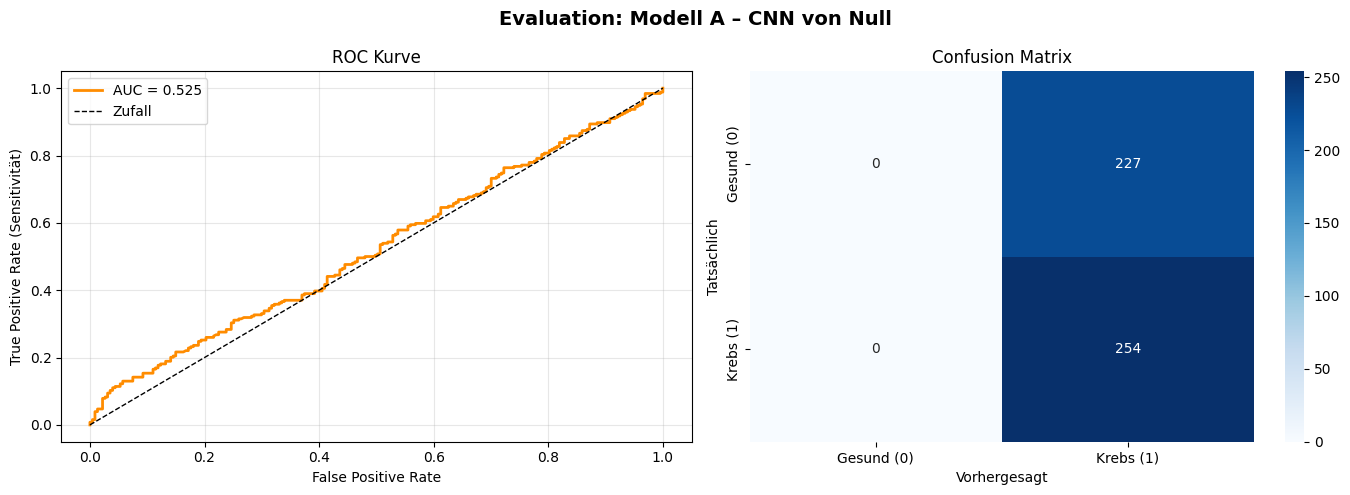

AUC: 0.5252
Accuracy: 0.5281
              precision    recall  f1-score   support

      Gesund       0.00      0.00      0.00       227
       Krebs       0.53      1.00      0.69       254

    accuracy                           0.53       481
   macro avg       0.26      0.50      0.35       481
weighted avg       0.28      0.53      0.36       481



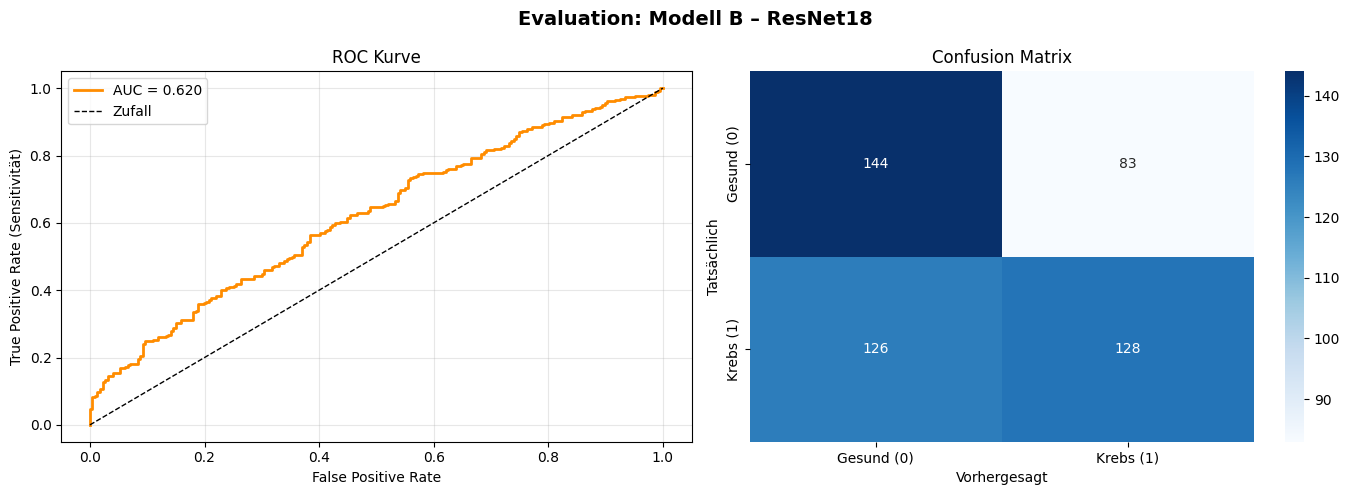

AUC: 0.6195
Accuracy: 0.5655
              precision    recall  f1-score   support

      Gesund       0.53      0.63      0.58       227
       Krebs       0.61      0.50      0.55       254

    accuracy                           0.57       481
   macro avg       0.57      0.57      0.57       481
weighted avg       0.57      0.57      0.56       481



In [10]:
def lade_bestes_modell(modell, pfad):
    if os.path.exists(pfad):
        modell.load_state_dict(torch.load(pfad, map_location=DEVICE, weights_only=True))
        print(f'Gewichte geladen: {pfad}')
    return modell


def evaluiere_modell(modell, loader, modell_name='Modell',
                     schwellwert=0.5, mit_alter=False):
    """
    Vollständige Evaluation:
    ROC Kurve + AUC | Confusion Matrix | Precision, Recall, F1
    Gibt (auc_wert, fpr, tpr, cm, labels_arr, preds_arr, alle_meta) zurück
    → labels und preds werden für Metadaten-Analyse weiterverwendet.
    """
    modell.eval()
    alle_labels, alle_preds, alle_meta = [], [], []

    with torch.no_grad():
        for batch in loader:
            if mit_alter:
                bilder, labels, alter, meta = batch
                vorhersagen = modell(bilder.to(DEVICE), alter.to(DEVICE))
            else:
                bilder, labels, meta = batch
                vorhersagen = modell(bilder.to(DEVICE))

            alle_labels.extend(labels.numpy())
            alle_preds.extend(vorhersagen.cpu().numpy().flatten())
            for i in range(len(labels)):
                alle_meta.append({
                    k: (v[i].item() if hasattr(v[i], 'item') else v[i])
                    for k, v in meta.items()
                })

    labels_arr = np.array(alle_labels)
    preds_arr  = np.array(alle_preds)
    klassen    = (preds_arr >= schwellwert).astype(int)

    fpr, tpr, _ = roc_curve(labels_arr, preds_arr)
    roc_auc     = auc(fpr, tpr)

    fig, achsen = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Evaluation: {modell_name}', fontsize=14, fontweight='bold')

    achsen[0].plot(fpr, tpr, color='darkorange', lw=2,
                   label=f'AUC = {roc_auc:.3f}')
    achsen[0].plot([0,1],[0,1],'k--', lw=1, label='Zufall')
    achsen[0].set_xlabel('False Positive Rate')
    achsen[0].set_ylabel('True Positive Rate (Sensitivität)')
    achsen[0].set_title('ROC Kurve')
    achsen[0].legend(); achsen[0].grid(alpha=0.3)

    cm = confusion_matrix(labels_arr, klassen)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=achsen[1],
                xticklabels=['Gesund (0)', 'Krebs (1)'],
                yticklabels=['Gesund (0)', 'Krebs (1)'])
    achsen[1].set_xlabel('Vorhergesagt')
    achsen[1].set_ylabel('Tatsächlich')
    achsen[1].set_title('Confusion Matrix')

    plt.tight_layout(); plt.show()

    print(f'AUC: {roc_auc:.4f}')
    print(f'Accuracy: {(klassen == labels_arr).mean():.4f}')
    print(classification_report(labels_arr, klassen,
                                  target_names=['Gesund', 'Krebs'],
                                  zero_division=0))

    return roc_auc, fpr, tpr, cm, labels_arr, preds_arr, alle_meta


# Beste Modelle laden und evaluieren
modell_a = lade_bestes_modell(modell_a, MODELL_PFAD_A)
modell_b = lade_bestes_modell(modell_b, MODELL_PFAD_B)

auc_a, fpr_a, tpr_a, cm_a, labels_a, preds_a, meta_a = evaluiere_modell(
    modell_a, loader_val_a, 'Modell A – CNN von Null')
auc_b, fpr_b, tpr_b, cm_b, labels_b, preds_b, meta_b = evaluiere_modell(
    modell_b, loader_val_b, 'Modell B – ResNet18')

## 9. Metadaten-Analyse A – Performance nach Altersgruppe

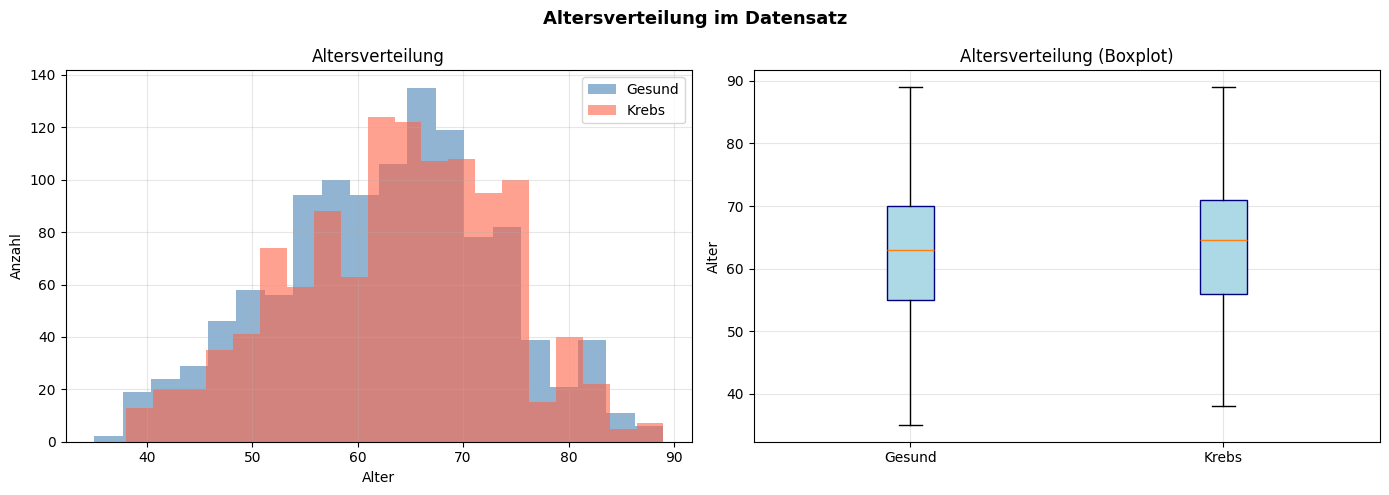

Ø Alter Gesund: 62.7 | Ø Alter Krebs: 63.7

Krebs-Prävalenz nach Altersgruppe:
altersgruppe
<40      0.3824
40-50    0.4640
50-60    0.4757
60-70    0.5048
>70      0.5392
Name: cancer, dtype: float64


In [11]:
# a. Altersverteilung im Datensatz
fig, achsen = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Altersverteilung im Datensatz', fontsize=13, fontweight='bold')

for label, farbe, name in [(0, 'steelblue', 'Gesund'), (1, 'tomato', 'Krebs')]:
    alter = df[df['cancer'] == label]['age'].dropna()
    achsen[0].hist(alter, bins=20, alpha=0.6, color=farbe, label=name)
achsen[0].set_xlabel('Alter'); achsen[0].set_ylabel('Anzahl')
achsen[0].set_title('Altersverteilung')
achsen[0].legend(); achsen[0].grid(alpha=0.3)

gesund_alter = df[df['cancer']==0]['age'].dropna()
krebs_alter  = df[df['cancer']==1]['age'].dropna()
achsen[1].boxplot([gesund_alter, krebs_alter], tick_labels=['Gesund', 'Krebs'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='navy'))
achsen[1].set_ylabel('Alter')
achsen[1].set_title('Altersverteilung (Boxplot)')
achsen[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Ø Alter Gesund: {gesund_alter.mean():.1f} | Ø Alter Krebs: {krebs_alter.mean():.1f}')
print('\nKrebs-Prävalenz nach Altersgruppe:')
print(df.groupby('altersgruppe', observed = False)['cancer'].mean().round(4))


Modell A – CNN von Null – AUC nach Altersgruppe:
Gruppe            N      AUC
------------------------------
<40               5  zu wenig Daten
40-50            69   0.4856
50-60           136   0.5159
60-70           160   0.5299
>70             111   0.5482


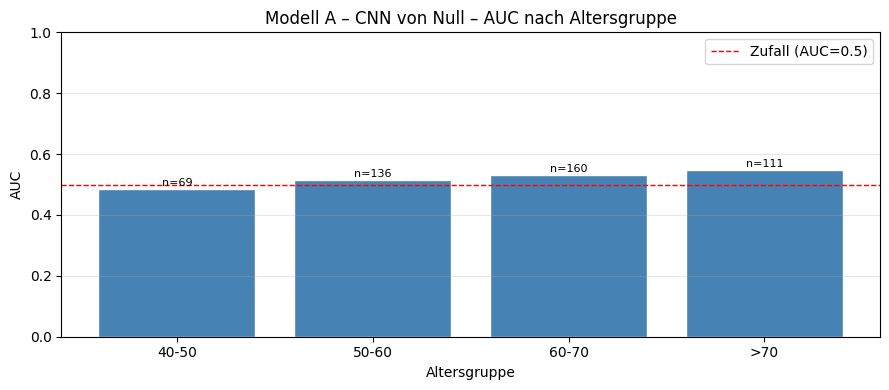


Modell B – ResNet18 – AUC nach Altersgruppe:
Gruppe            N      AUC
------------------------------
<40               5  zu wenig Daten
40-50            69   0.5346
50-60           136   0.6223
60-70           160   0.6083
>70             111   0.7059


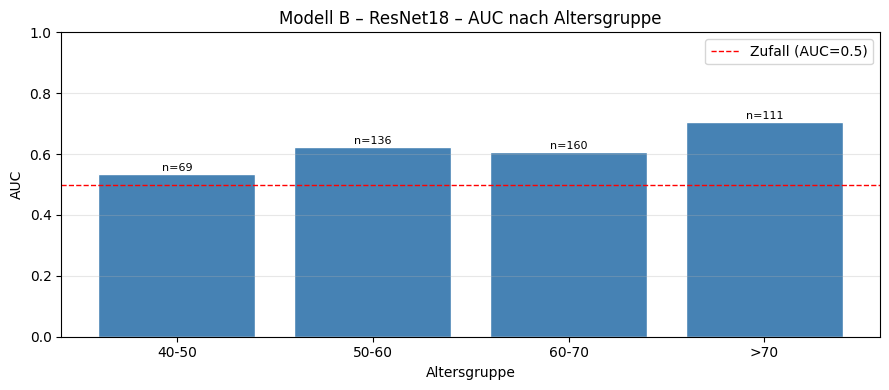

In [12]:
# b. Modell-Performance nach Altersgruppe
# Gibt es Altersgruppen bei denen das Modell besser/schlechter ist?

def performance_nach_altersgruppe(labels, preds, meta, modell_name):
    """
    Berechnet AUC pro Altersgruppe und zeigt ob das Modell
    bei bestimmten Altersgruppen systematisch besser/schlechter ist.
    """
    df_eval = pd.DataFrame({
        'label':        labels,
        'pred':         preds,
        'altersgruppe': [m['altersgruppe'] for m in meta],
        'age':          [m['age'] for m in meta]
    })

    gruppen    = ['<40', '40-50', '50-60', '60-70', '>70']
    auc_werte  = []
    n_werte    = []

    print(f'\n{modell_name} – AUC nach Altersgruppe:')
    print(f'{"Gruppe":<12} {"N":>6} {"AUC":>8}')
    print('-' * 30)

    for gruppe in gruppen:
        teilmenge = df_eval[df_eval['altersgruppe'] == gruppe]
        n = len(teilmenge)
        if n < 10 or teilmenge['label'].nunique() < 2:
            auc_werte.append(None)
            n_werte.append(n)
            print(f'{gruppe:<12} {n:>6}  zu wenig Daten')
            continue
        fpr_g, tpr_g, _ = roc_curve(teilmenge['label'], teilmenge['pred'])
        auc_g = auc(fpr_g, tpr_g)
        auc_werte.append(auc_g)
        n_werte.append(n)
        print(f'{gruppe:<12} {n:>6} {auc_g:>8.4f}')

    # Balkendiagramm
    gueltige = [(g, a, n) for g, a, n in zip(gruppen, auc_werte, n_werte) if a is not None]
    if gueltige:
        g_namen, g_auc, g_n = zip(*gueltige)
        fig, ax = plt.subplots(figsize=(9, 4))
        balken = ax.bar(g_namen, g_auc, color='steelblue', edgecolor='white')
        ax.axhline(y=0.5, color='red', linestyle='--', lw=1, label='Zufall (AUC=0.5)')
        ax.set_xlabel('Altersgruppe'); ax.set_ylabel('AUC')
        ax.set_title(f'{modell_name} – AUC nach Altersgruppe')
        ax.set_ylim(0, 1); ax.legend(); ax.grid(axis='y', alpha=0.3)
        for balken_i, n in zip(balken, g_n):
            ax.text(balken_i.get_x() + balken_i.get_width()/2,
                    balken_i.get_height() + 0.01,
                    f'n={n}', ha='center', fontsize=8)
        plt.tight_layout(); plt.show()

    return df_eval


df_eval_a = performance_nach_altersgruppe(labels_a, preds_a, meta_a, 'Modell A – CNN von Null')
df_eval_b = performance_nach_altersgruppe(labels_b, preds_b, meta_b, 'Modell B – ResNet18')

## 10. Metadaten-Analyse B – Alter als zusätzlicher Modell-Input (Multimodal)

In [13]:
# Multimodales Modell
# Idee: Bild durch ResNet18 -> 512 Features + normalisiertes Alter (1 Zahl) -> zusammen in finalen Classifier
# WICHTIG: Backbone wird eingefroren (wie bei Modell B), damit dies ein fairer
# "Modell B + Alter"-Vergleich ist. 


class ResNet18Multimodal(nn.Module):
    """
    ResNet18 + Alter als zusätzlicher Input.
    Bild-Features (512) werden mit dem Alter (1) concateniert
    und dann gemeinsam klassifiziert.
    """
    def __init__(self):
        super().__init__()
        basis = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Backbone: alles ausser dem letzten FC Layer
        self.backbone = nn.Sequential(*list(basis.children())[:-1])

        # Backbone zunächst komplett einfrieren (Phase 1: Feature Extraction)
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Finaler Classifier: 512 (Bild) + 1 (Alter) = 513 Eingaben
        self.classifier = nn.Sequential(
            nn.Linear(512 + 1, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, bild, alter):
        # Bild-Features extrahieren
        bild_features = self.backbone(bild)          # (batch, 512, 1, 1)
        bild_features = torch.flatten(bild_features, 1)  # (batch, 512)

        # Bild-Features + Alter zusammenführen
        kombiniert = torch.cat([bild_features, alter], dim=1)  # (batch, 513)

        return self.classifier(kombiniert)


def auftauen_modell_c_finetuning(modell):
    """Phase 2 für Modell C: nur layer4[1] des Backbones + Classifier auftauen,
    analog zu auftauen_fuer_finetuning() bei Modell B. Im gewrappten Sequential
    (backbone) ist layer4 an Index 7 (conv1,bn1,relu,maxpool,layer1,layer2,
    layer3,layer4,avgpool)."""
    for param in modell.backbone.parameters():
        param.requires_grad = False
    for param in modell.backbone[7][1].parameters():
        param.requires_grad = True
    for param in modell.classifier.parameters():
        param.requires_grad = True


modell_c = ResNet18Multimodal().to(DEVICE)
params_c  = sum(p.numel() for p in modell_c.parameters() if p.requires_grad)
print(f'Modell C - ResNet18 + Alter (Multimodal), Phase 1: {params_c:,} trainierbare Parameter')


Modell C - ResNet18 + Alter (Multimodal), Phase 1: 65,921 trainierbare Parameter


Train: 1,835 | Val: 481 Bilder
TRAINING MODELL C - Phase 1: Feature Extraction (5 Epochen)
  -> Gespeichert (Val Loss: 0.6930)
Epoche  1/5 | Train: 0.7065 | Val: 0.6930 | AUC: 0.4819
  -> Gespeichert (Val Loss: 0.6928)
Epoche  2/5 | Train: 0.6963 | Val: 0.6928 | AUC: 0.5120
Epoche  3/5 | Train: 0.6938 | Val: 0.6935 | AUC: 0.5220
Epoche  4/5 | Train: 0.6936 | Val: 0.6936 | AUC: 0.4941
Epoche  5/5 | Train: 0.6931 | Val: 0.6935 | AUC: 0.4942

Phase 1 fertig in 1m 29s (17.9s pro Epoche)

TRAINING MODELL C - Phase 2: Fine-Tuning layer4[1] (10 Epochen)
Trainierbare Parameter Phase 2: 4,786,561
  -> Gespeichert (Val Loss: 0.6934)
Epoche  1/10 | Train: 0.6930 | Val: 0.6934 | AUC: 0.4938
  -> Gespeichert (Val Loss: 0.6933)
Epoche  2/10 | Train: 0.6929 | Val: 0.6933 | AUC: 0.5176
Epoche  3/10 | Train: 0.6919 | Val: 0.6964 | AUC: 0.4305
  -> Gespeichert (Val Loss: 0.6925)
Epoche  4/10 | Train: 0.6903 | Val: 0.6925 | AUC: 0.5039
  -> Gespeichert (Val Loss: 0.6817)
Epoche  5/10 | Train: 0.6885 | Va

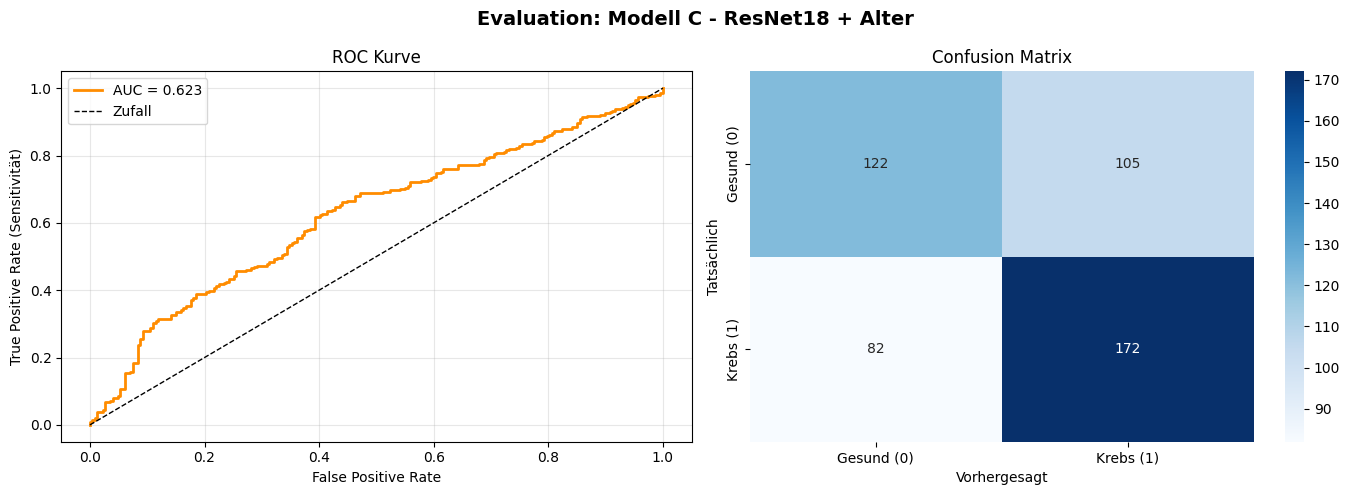

AUC: 0.6235
Accuracy: 0.6112
              precision    recall  f1-score   support

      Gesund       0.60      0.54      0.57       227
       Krebs       0.62      0.68      0.65       254

    accuracy                           0.61       481
   macro avg       0.61      0.61      0.61       481
weighted avg       0.61      0.61      0.61       481



In [14]:
# DataLoader für multimodales Modell (mit_alter=True)
loader_train_c, loader_val_c, _, _ = erstelle_dataloaders(
    df, fuer_resnet18=True, mit_alter=True)

print('=' * 60)
print('TRAINING MODELL C - Phase 1: Feature Extraction (5 Epochen)')
print('=' * 60)
t0 = time.time()
history_c_phase1 = trainiere_modell(
    modell_c, loader_train_c, loader_val_c,
    epochen=5, lernrate=1e-3, speicher_pfad=MODELL_PFAD_C, mit_alter=True)
dauer_c1 = time.time() - t0
print(f'\nPhase 1 fertig in {fmt_zeit(dauer_c1)} '
      f'({dauer_c1/5:.1f}s pro Epoche)', flush=True)

print('\n' + '=' * 60)
print('TRAINING MODELL C - Phase 2: Fine-Tuning layer4[1] (10 Epochen)')
print('=' * 60)
auftauen_modell_c_finetuning(modell_c)
params_c_phase2 = sum(p.numel() for p in modell_c.parameters() if p.requires_grad)
print(f'Trainierbare Parameter Phase 2: {params_c_phase2:,}', flush=True)
t0 = time.time()
history_c_phase2 = trainiere_modell(
    modell_c, loader_train_c, loader_val_c,
    epochen=10, lernrate=1e-4, speicher_pfad=MODELL_PFAD_C, mit_alter=True,
    weight_decay=1e-3)
dauer_c2 = time.time() - t0
print(f'\nPhase 2 fertig in {fmt_zeit(dauer_c2)} '
      f'({dauer_c2/10:.1f}s pro Epoche)', flush=True)
print(f'Modell C gesamt: {fmt_zeit(dauer_c1 + dauer_c2)}', flush=True)

# Gesamte History zusammenführen (wie bei Modell B)
history_c = {
    k: history_c_phase1[k] + history_c_phase2[k]
    for k in ['train_loss', 'val_loss', 'val_auc']
}

modell_c = lade_bestes_modell(modell_c, MODELL_PFAD_C)
auc_c, fpr_c, tpr_c, cm_c, labels_c, preds_c, meta_c = evaluiere_modell(
    modell_c, loader_val_c, 'Modell C - ResNet18 + Alter', mit_alter=True)


## 11. Metadaten-Analyse C – BIRADS & Brustdichte

BIRADS  vorhanden: 972 / 2316 Bilder
Density vorhanden: 1336 / 2316 Bilder



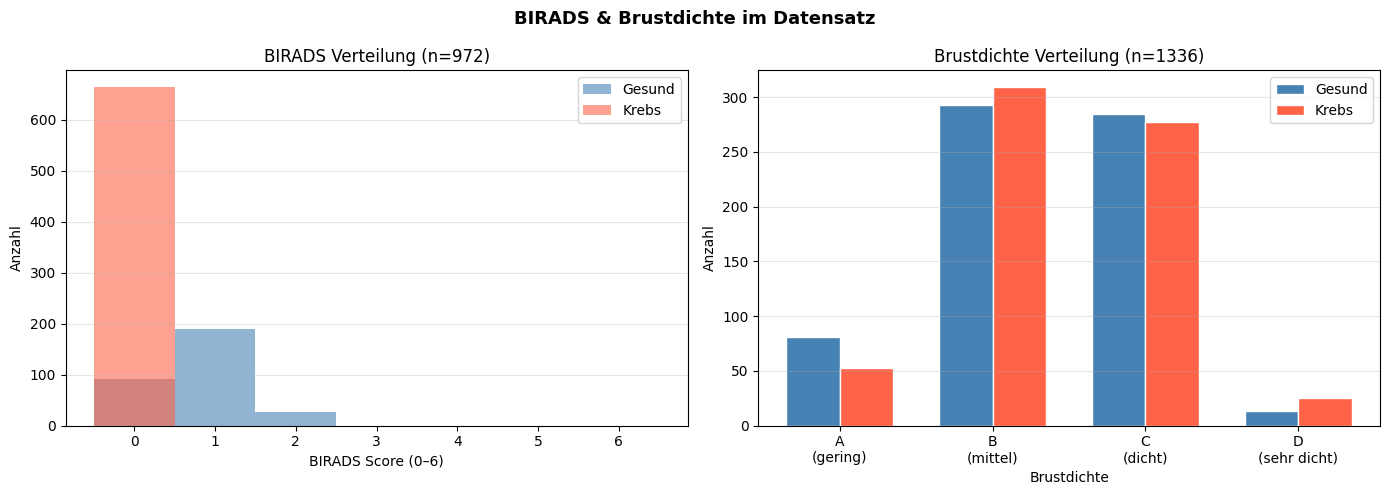

Krebs-Prävalenz nach BIRADS Score:


,Krebs-Anteil,Anzahl
BIRADS,,
0.0,0.8783,756
1.0,0.0000,189
2.0,0.0000,27



Krebs-Prävalenz nach Brustdichte:


,Krebs-Anteil,Anzahl
density,,
A,0.3955,134
B,0.5133,602
C,0.4929,562
D,0.6579,38



── Validierungsset – BIRADS & Density pro Bild ──────────────────


,patient_id,age,BIRADS,density,label,pred_a,pred_b
0,5820,65.0,0.0,B,1.0,0.511,0.511
1,14769,50.0,NaN,NaN,1.0,0.511,0.452
2,40931,77.0,NaN,NaN,0.0,0.510,0.328
3,32743,60.0,NaN,C,0.0,0.511,0.404
4,49130,59.0,2.0,B,0.0,0.512,0.613
...,...,...,...,...,...,...,...
476,57062,59.0,1.0,C,0.0,0.512,0.430
477,31750,61.0,NaN,B,0.0,0.509,0.251
478,19159,54.0,0.0,C,1.0,0.511,0.522
479,6654,50.0,NaN,NaN,1.0,0.512,0.493


In [15]:
# BIRADS & Brustdichte – Verteilung & Modell-Performance

print(f'BIRADS  vorhanden: {df["BIRADS"].notna().sum():>3} / {len(df)} Bilder')
print(f'Density vorhanden: {df["density"].notna().sum():>3} / {len(df)} Bilder\n')

# Verteilung im balancierten Datensatz
fig, achsen = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BIRADS & Brustdichte im Datensatz', fontsize=13, fontweight='bold')

# BIRADS
birads_df = df.dropna(subset=['BIRADS'])
if len(birads_df) > 0:
    for label, farbe, name in [(0, 'steelblue', 'Gesund'), (1, 'tomato', 'Krebs')]:
        achsen[0].hist(birads_df[birads_df['cancer']==label]['BIRADS'],
                       bins=range(0, 8), alpha=0.6, color=farbe, label=name, align='left')
    achsen[0].set_xlabel('BIRADS Score (0–6)')
    achsen[0].set_ylabel('Anzahl')
    achsen[0].set_title(f'BIRADS Verteilung (n={len(birads_df)})')
    achsen[0].set_xticks(range(0, 7))
    achsen[0].legend(); achsen[0].grid(axis='y', alpha=0.3)
else:
    achsen[0].text(0.5, 0.5, 'Keine BIRADS-Daten verfügbar', ha='center', va='center', fontsize=12)
    achsen[0].set_title('BIRADS – keine Daten')

# Density
density_df = df.dropna(subset=['density'])
if len(density_df) > 0:
    density_werte = sorted(density_df['density'].unique())
    breite = 0.35
    x = range(len(density_werte))
    n_gesund = [len(density_df[(density_df['cancer']==0) & (density_df['density']==d)]) for d in density_werte]
    n_krebs  = [len(density_df[(density_df['cancer']==1) & (density_df['density']==d)]) for d in density_werte]
    achsen[1].bar([i - breite/2 for i in x], n_gesund, breite, label='Gesund', color='steelblue', edgecolor='white')
    achsen[1].bar([i + breite/2 for i in x], n_krebs,  breite, label='Krebs',  color='tomato',    edgecolor='white')
    achsen[1].set_xticks(list(x))
    achsen[1].set_xticklabels([f'{d}\n({"gering" if d=="A" else "mittel" if d=="B" else "dicht" if d=="C" else "sehr dicht"})' for d in density_werte])
    achsen[1].set_xlabel('Brustdichte'); achsen[1].set_ylabel('Anzahl')
    achsen[1].set_title(f'Brustdichte Verteilung (n={len(density_df)})')
    achsen[1].legend(); achsen[1].grid(axis='y', alpha=0.3)
else:
    achsen[1].text(0.5, 0.5, 'Keine Density-Daten verfügbar', ha='center', va='center', fontsize=12)
    achsen[1].set_title('Brustdichte – keine Daten')

plt.tight_layout(); plt.show()

# Krebs-Prävalenz nach BIRADS & Density
if df['BIRADS'].notna().sum() > 0:
    print('Krebs-Prävalenz nach BIRADS Score:')
    birads_stats = df.groupby('BIRADS')['cancer'].agg(['mean', 'count'])
    birads_stats.columns = ['Krebs-Anteil', 'Anzahl']
    display(birads_stats.round(4))

if df['density'].notna().sum() > 0:
    print('\nKrebs-Prävalenz nach Brustdichte:')
    density_stats = df.groupby('density')['cancer'].agg(['mean', 'count'])
    density_stats.columns = ['Krebs-Anteil', 'Anzahl']
    display(density_stats.round(4))

# Validierungsset: Vorhersagen je BIRADS & Density 
# df_val hat dieselbe Reihenfolge wie loader_val_a (shuffle=False) --> labels_a und preds_a können direkt zugeordnet werden
df_val_analyse = df_val.reset_index(drop=True).copy()
df_val_analyse['label']  = labels_a.flatten()
df_val_analyse['pred_a'] = preds_a
df_val_analyse['pred_b'] = preds_b

print('\n── Validierungsset – BIRADS & Density pro Bild ──────────────────')
spalten = ['patient_id', 'age', 'BIRADS', 'density', 'label', 'pred_a', 'pred_b']
display(df_val_analyse[spalten].round(3))

## 12. PCA Visualisierung

Erklärte Varianz – PC1: 18.7% | PC2: 9.4%


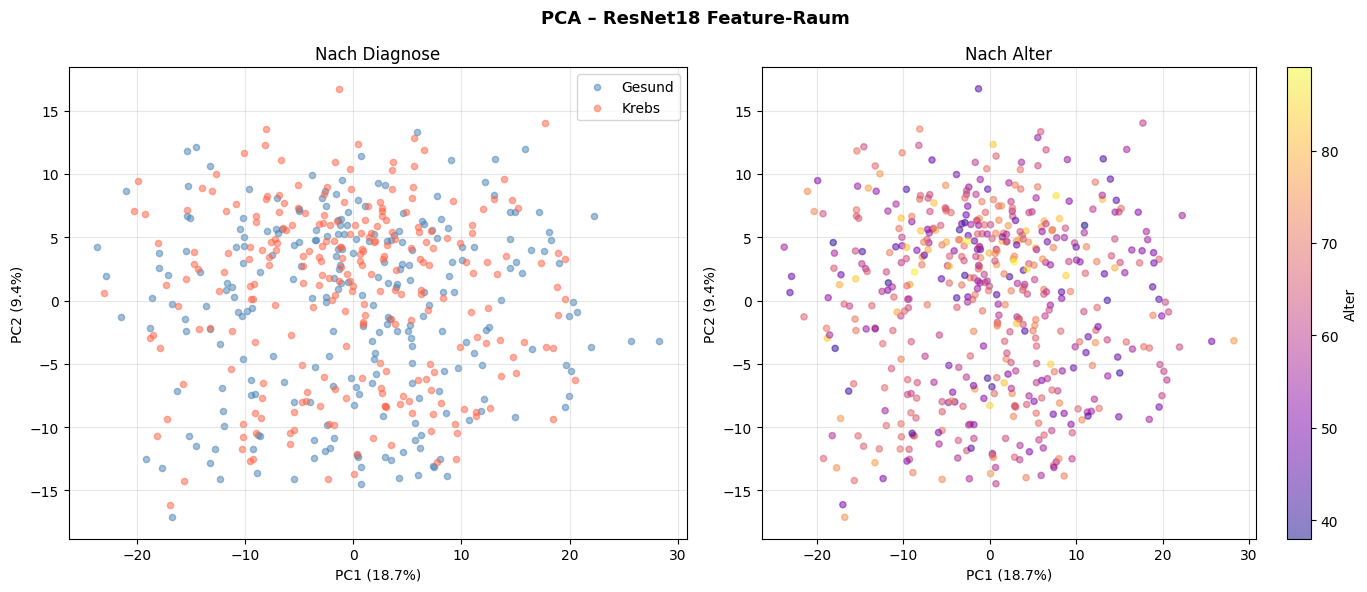

In [16]:
# PCA auf ResNet18 Features
# ResNet18 lernt 512 Zahlen pro Bild (die Features).
# PCA reduziert diese 512 auf 2 --> jeden Punkt in 2D plotten.
# Bilden Krebs und Gesund getrennte Cluster, spricht das für gut trennbare
# Features. Der Umkehrschluss gilt aber NICHT: PCA ist linear und
# unüberwacht, fehlende Trennung im 2D-Plot bedeutet nicht, dass das Modell
# nichts gelernt hat. Die Darstellung ist daher nur ein Anhaltspunkt.

class FeatureExtractor(nn.Module):
    """ResNet18 ohne FC Layer → gibt 512-dim Features zurück."""
    def __init__(self, basis_modell):
        super().__init__()
        self.backbone = nn.Sequential(*list(basis_modell.children())[:-1])

    def forward(self, x):
        return torch.flatten(self.backbone(x), 1)


extraktor = FeatureExtractor(modell_b).to(DEVICE)
extraktor.eval()

# Teilmenge für PCA (500 Bilder reichen)
df_pca_sample = df.sample(min(500, len(df)), random_state=ZUFALLSZAHL)
pca_loader = DataLoader(
    MammografieDataset(df_pca_sample, BILDER_ORDNER,
                        val_transforms_3kanal, fuer_resnet18=True),
    batch_size=16, shuffle=False
)

alle_features, alle_labels, alle_alter = [], [], []

with torch.no_grad():
    for bilder, labels, meta in pca_loader:
        features = extraktor(bilder.to(DEVICE))
        alle_features.append(features.cpu().numpy())
        alle_labels.extend(labels.numpy())
        alle_alter.extend(
            [v.item() if hasattr(v, 'item') else v for v in meta['age']])

features_matrix = np.vstack(alle_features)
labels_array    = np.array(alle_labels)
alter_array     = np.array(alle_alter, dtype=float)

# PCA auf 2 Komponenten
features_norm = StandardScaler().fit_transform(features_matrix)
pca           = PCA(n_components=2, random_state=ZUFALLSZAHL)
pcs           = pca.fit_transform(features_norm)

print(f'Erklärte Varianz – PC1: {pca.explained_variance_ratio_[0]:.1%} | '
      f'PC2: {pca.explained_variance_ratio_[1]:.1%}')

fig, achsen = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('PCA – ResNet18 Feature-Raum', fontsize=13, fontweight='bold')

# Eingefärbt nach Diagnose
for label, farbe, name in [(0, 'steelblue', 'Gesund'), (1, 'tomato', 'Krebs')]:
    maske = labels_array == label
    achsen[0].scatter(pcs[maske,0], pcs[maske,1],
                      c=farbe, alpha=0.5, s=20, label=name)
achsen[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
achsen[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
achsen[0].set_title('Nach Diagnose')
achsen[0].legend(); achsen[0].grid(alpha=0.3)

# Eingefärbt nach Alter
gueltig = alter_array > 0
sc = achsen[1].scatter(pcs[gueltig,0], pcs[gueltig,1],
                        c=alter_array[gueltig], cmap='plasma', alpha=0.5, s=20)
plt.colorbar(sc, ax=achsen[1], label='Alter')
achsen[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
achsen[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
achsen[1].set_title('Nach Alter')
achsen[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 13. Architektur-Vergleich

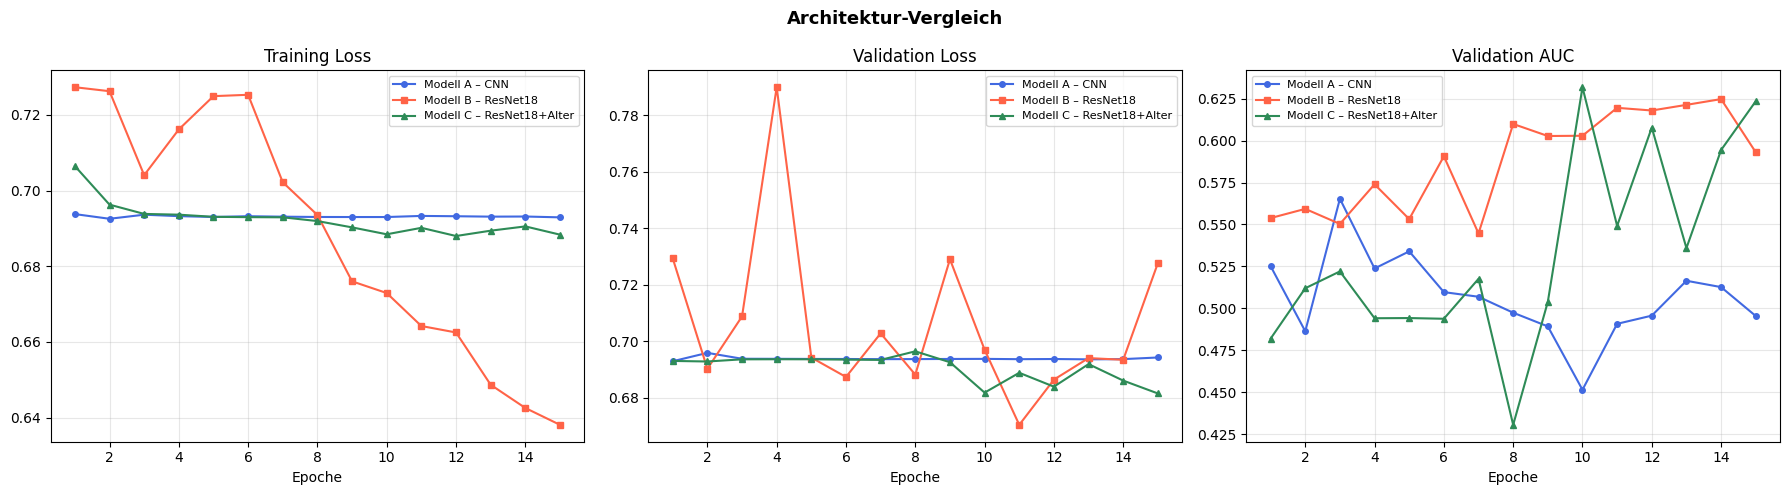

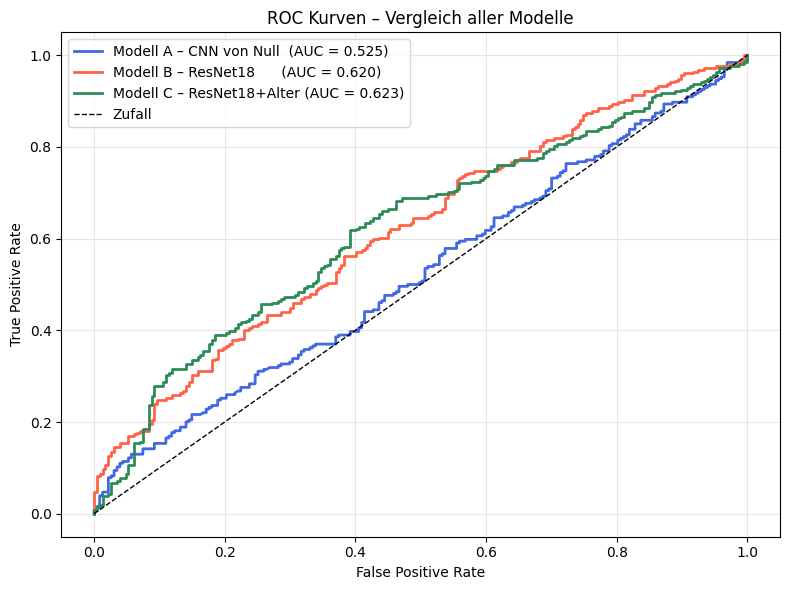


 ZUSAMMENFASSUNG ALLER MODELLE 


,Modell,Trainierb. Param.,Bester Val Loss,Bester Val AUC,Test AUC
0,A – CNN von Null,"1,072,385",0.6929,0.5653,0.5252
1,B – ResNet18,"4,721,153",0.6703,0.6248,0.6195
2,C – ResNet18+Alter,"4,786,561",0.6815,0.6318,0.6235


In [17]:
#Trainings-Kurven
fig, achsen = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Architektur-Vergleich', fontsize=13, fontweight='bold')

e = range(1, len(history_a['train_loss']) + 1)
farben   = ['royalblue', 'tomato', 'seagreen']
symbole  = ['-o', '-s', '-^']
modelle  = [
    ('Modell A – CNN', history_a),
    ('Modell B – ResNet18', history_b),
    ('Modell C – ResNet18+Alter', history_c)
]

for titel, metrik, idx in [
    ('Training Loss',    'train_loss', 0),
    ('Validation Loss',  'val_loss',   1),
    ('Validation AUC',   'val_auc',    2)
]:
    for (name, hist), farbe, sym in zip(modelle, farben, symbole):
        achsen[idx].plot(e, hist[metrik], sym, color=farbe, ms=4, label=name)
    achsen[idx].set_title(titel)
    achsen[idx].set_xlabel('Epoche')
    achsen[idx].legend(fontsize=8)
    achsen[idx].grid(alpha=0.3)

plt.tight_layout(); plt.show()


#ROC Kurven übereinander
plt.figure(figsize=(8, 6))
plt.plot(fpr_a, tpr_a, color='royalblue', lw=2,
         label=f'Modell A – CNN von Null  (AUC = {auc_a:.3f})')
plt.plot(fpr_b, tpr_b, color='tomato',    lw=2,
         label=f'Modell B – ResNet18      (AUC = {auc_b:.3f})')
plt.plot(fpr_c, tpr_c, color='seagreen',  lw=2,
         label=f'Modell C – ResNet18+Alter (AUC = {auc_c:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1, label='Zufall')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Kurven – Vergleich aller Modelle')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


#Zusammenfassungstabell
def n_params(modell):
    return sum(p.numel() for p in modell.parameters() if p.requires_grad)

vergleich = pd.DataFrame({
    'Modell':             ['A – CNN von Null', 'B – ResNet18', 'C – ResNet18+Alter'],
    'Trainierb. Param.':  [n_params(modell_a), n_params(modell_b), n_params(modell_c)],
    'Bester Val Loss':    [min(history_a['val_loss']),
                           min(history_b['val_loss']),
                           min(history_c['val_loss'])],
    'Bester Val AUC':     [max(history_a['val_auc']),
                           max(history_b['val_auc']),
                           max(history_c['val_auc'])],
    'Val AUC (final)':           [auc_a, auc_b, auc_c],
})

print('\n ZUSAMMENFASSUNG ALLER MODELLE ')
display(vergleich.style
    .highlight_max(subset=['Bester Val AUC', 'Val AUC (final)'], color='lightgreen')
    .highlight_min(subset=['Bester Val Loss'],             color='lightgreen')
    .format({
        'Bester Val Loss':   '{:.4f}',
        'Bester Val AUC':    '{:.4f}',
        'Val AUC (final)':          '{:.4f}',
        'Trainierb. Param.': '{:,}'
    })
)

## 14. Systematische Untersuchungen (E0 und E2)

Warum lernen die Netze kaum, und wie lässt sich die Performance verbessern?
Pro Experiment ändere ich nur eine Variable, sonst bleibt alles gleich.


E0 Overfit-Test auf nur 40 Bildern, ohne Augmentation:
  Epoche  10 | Train-Loss: 0.5664
  Epoche  20 | Train-Loss: 0.4256
  Epoche  30 | Train-Loss: 0.1241
  Epoche  40 | Train-Loss: 0.0253
  Epoche  50 | Train-Loss: 0.0141
  Epoche  60 | Train-Loss: 0.0010
  Epoche  70 | Train-Loss: 0.0092
  Epoche  80 | Train-Loss: 0.0007


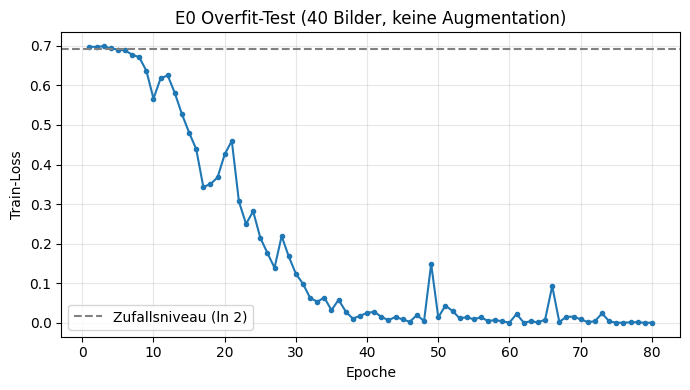


Start-Loss: 0.6978  ->  End-Loss: 0.0007
ERGEBNIS: Train-Loss geht klar gegen 0 -> die Pipeline lernt,
Das eigentliche Problem ist die Generalisierung (zu wenig Daten).


In [18]:
# E0 - Overfit-Test: Kann das Setup überhaupt lernen?
# Idee: Nehme absichtlich nur sehr wenige Bilder und KEINE Augmentation
# und trainiere viele Epochen. Geht der Train-Loss gegen 0, kann das Modell
# die Daten auswendig lernen -> die Pipeline ist korrekt (kein Bug). Das
# eigentliche Problem ist dann die Generalisierung, nicht der Code.
# Nutze Modell A (CNN von Null), weil genau dieses Modell auf dem vollen
# Datensatz einen flachen Train-Loss zeigte.

n_pro_klasse = 20
klein_df = pd.concat([
    df[df['cancer'] == 1].head(n_pro_klasse),
    df[df['cancer'] == 0].head(n_pro_klasse)
]).reset_index(drop=True)

# Dataset OHNE Augmentation (val_transforms), 1-Kanal wie Modell A
ds_overfit = MammografieDataset(klein_df, BILDER_ORDNER,
                                val_transforms_1kanal, fuer_resnet18=False)
loader_overfit = DataLoader(ds_overfit, batch_size=8, shuffle=True)

# Frisches Modell A
modell_overfit = EinfachesBrustkrebsCNN(in_kanale=1).to(DEVICE)
kriterium_o = nn.BCELoss()
optim_o = optim.Adam(modell_overfit.parameters(), lr=1e-3)

print(f'E0 Overfit-Test auf nur {len(klein_df)} Bildern, ohne Augmentation:')
overfit_loss = []
for ep in range(80):
    l = trainiere_eine_epoche(modell_overfit, loader_overfit, optim_o, kriterium_o)
    overfit_loss.append(l)
    if (ep + 1) % 10 == 0:
        print(f'  Epoche {ep+1:>3} | Train-Loss: {l:.4f}', flush=True)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(overfit_loss) + 1), overfit_loss, marker='o', ms=3)
plt.axhline(0.693, color='gray', ls='--', label='Zufallsniveau (ln 2)')
plt.xlabel('Epoche'); plt.ylabel('Train-Loss')
plt.title(f'E0 Overfit-Test ({len(klein_df)} Bilder, keine Augmentation)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f'\nStart-Loss: {overfit_loss[0]:.4f}  ->  End-Loss: {overfit_loss[-1]:.4f}')
if overfit_loss[-1] < 0.2:
    print('ERGEBNIS: Train-Loss geht klar gegen 0 -> die Pipeline lernt,')
    print('Das eigentliche Problem ist die Generalisierung (zu wenig Daten).')
else:
    print('ERGEBNIS: Train-Loss bleibt hoch -> Hinweis auf ein Pipeline-Problem.')


Train: 1869 Bilder (Krebs 945 / Gesund 924)
Val:   447 Bilder | pos_weight = 0.98

E2 Training (alle Daten + pos_weight, 30 Epochen):
  Epoche  1/30 | Train 0.7237 | Val 0.6868 | AUC 0.5688  *bestes*
  Epoche  2/30 | Train 0.6946 | Val 0.6857 | AUC 0.6144  *bestes*
  Epoche  3/30 | Train 0.6993 | Val 0.6754 | AUC 0.6069
  Epoche  4/30 | Train 0.6834 | Val 0.6869 | AUC 0.5986
  Epoche  5/30 | Train 0.6756 | Val 0.6704 | AUC 0.6118
  Epoche  6/30 | Train 0.6721 | Val 0.6754 | AUC 0.6268  *bestes*
  Epoche  7/30 | Train 0.6590 | Val 0.6871 | AUC 0.6045
  Epoche  8/30 | Train 0.6592 | Val 0.6782 | AUC 0.6100
  Epoche  9/30 | Train 0.6502 | Val 0.6676 | AUC 0.6423  *bestes*
  Epoche 10/30 | Train 0.6381 | Val 0.6844 | AUC 0.6111
  Epoche 11/30 | Train 0.6428 | Val 0.6936 | AUC 0.6063
  Epoche 12/30 | Train 0.6313 | Val 0.7027 | AUC 0.6079
  Epoche 13/30 | Train 0.6341 | Val 0.6967 | AUC 0.6164
  Epoche 14/30 | Train 0.6148 | Val 0.6897 | AUC 0.6121 | LR: 1.0e-04 -> 5.0e-05
  Epoche 15/30 | 

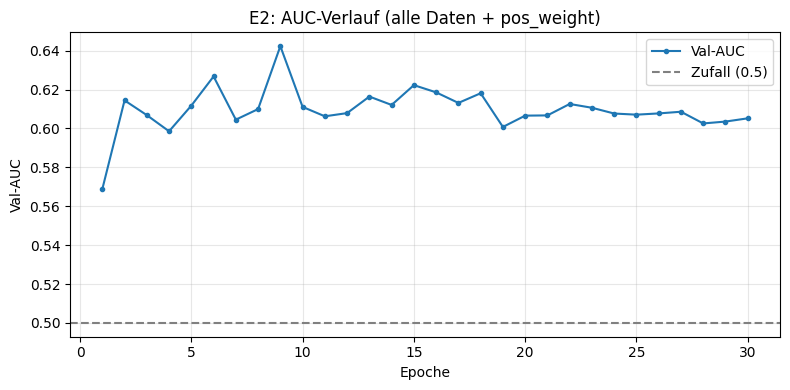


              precision    recall  f1-score   support

      Gesund       0.64      0.51      0.57       234
       Krebs       0.56      0.69      0.62       213

    accuracy                           0.60       447
   macro avg       0.60      0.60      0.59       447
weighted avg       0.60      0.60      0.59       447

Hinweis: AUC und Krebs-Recall mit der 50/50-Balancierung (Modell B) vergleichen.


In [19]:
# E2 - Klassengewichtung (pos_weight) statt Undersampling
# Ursprüngliche Idee: Statt auf 50/50 zu undersamplen (und dabei Gesund-Bilder
# wegzuwerfen), ALLE verfügbaren Bilder nutzen und die Schieflage über pos_weight
# in der Loss ausgleichen. Patient-Split wie im Hauptteil (kein Data Leakage).
#
# WICHTIG (Stand nach der Datensatz-Erweiterung): Der Datensatz ist inzwischen
# exakt balanciert, das Undersampling in Abschnitt 3 wirft daher kein Bild mehr
# weg. Beide Ansätze nutzen dieselben 2316 Bilder, und pos_weight liegt bei rund
# 0.98, gleicht also nur noch die minimale Verschiebung aus, die der
# patientenweise Split verursacht. E2 vergleicht damit faktisch nicht mehr die
# Datenmenge, sondern die Verlustfunktion (BCEWithLogitsLoss statt BCELoss) und
# das Trainingsregime (30 Epochen einphasig statt 5+10 zweiphasig).
# Längeres Training (30 Epochen), LR-Scheduler, bestes Modell wird gespeichert.

# 1) Patient-Split auf allen verfügbaren Daten
patienten_voll = df_verfuegbar['patient_id'].unique()
rng_v = np.random.default_rng(ZUFALLSZAHL)
rng_v.shuffle(patienten_voll)
n_val_v = int(len(patienten_voll) * VAL_ANTEIL)
val_pat_v = set(patienten_voll[:n_val_v])
df_v_val = df_verfuegbar[df_verfuegbar['patient_id'].isin(val_pat_v)]
df_v_train = df_verfuegbar[~df_verfuegbar['patient_id'].isin(val_pat_v)]

n_pos = int((df_v_train['cancer'] == 1).sum())
n_neg = int((df_v_train['cancer'] == 0).sum())
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=DEVICE)
print(f'Train: {len(df_v_train)} Bilder (Krebs {n_pos} / Gesund {n_neg})')
print(f'Val:   {len(df_v_val)} Bilder | pos_weight = {n_neg/n_pos:.2f}')

# 2) Dataloader (3-Kanal für ResNet)
ds_tr = MammografieDataset(df_v_train, BILDER_ORDNER, train_transforms_3kanal, fuer_resnet18=True)
ds_va = MammografieDataset(df_v_val,   BILDER_ORDNER, val_transforms_3kanal,   fuer_resnet18=True)
ld_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                   num_workers=0, pin_memory=torch.cuda.is_available())
ld_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False,
                   num_workers=0, pin_memory=torch.cuda.is_available())

# 3) ResNet18 mit LOGIT-Ausgabe (kein Sigmoid), letzter Block aufgetaut.
modell_e2 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for p in modell_e2.parameters():
    p.requires_grad = False
for p in modell_e2.layer4[1].parameters():
    p.requires_grad = True
modell_e2.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(modell_e2.fc.in_features, 1))
modell_e2 = modell_e2.to(DEVICE)

kriterium_e2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optim_e2 = optim.Adam(filter(lambda p: p.requires_grad, modell_e2.parameters()),
                      lr=1e-4, weight_decay=1e-4)
# Scheduler auf die Val-AUC (mode max), weil der Val-Loss durch pos_weight verzerrt ist
scheduler_e2 = optim.lr_scheduler.ReduceLROnPlateau(optim_e2, mode='max', factor=0.5, patience=4)

# 4) Training. AUC ist rang basiert daher mit Logits korrekt berechenbar.
E2_EPOCHEN = 30
E2_PFAD = 'modell_e2_voll.pth'
e2_history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
bester_e2_auc = 0.0

print('\nE2 Training (alle Daten + pos_weight, 30 Epochen):')
for ep in range(E2_EPOCHEN):
    tl = trainiere_eine_epoche(modell_e2, ld_tr, optim_e2, kriterium_e2)
    vl, labs, preds = validiere(modell_e2, ld_va, kriterium_e2)
    fpr, tpr, _ = roc_curve(labs, preds)
    a = auc(fpr, tpr)
    e2_history['train_loss'].append(tl)
    e2_history['val_loss'].append(vl)
    e2_history['val_auc'].append(a)

    lr_vor = optim_e2.param_groups[0]['lr']
    scheduler_e2.step(a)
    lr_nach = optim_e2.param_groups[0]['lr']
    lr_info = f' | LR: {lr_vor:.1e} -> {lr_nach:.1e}' if lr_nach != lr_vor else ''

    if a > bester_e2_auc:
        bester_e2_auc = a
        torch.save(modell_e2.state_dict(), E2_PFAD)
        marker = '  *bestes*'
    else:
        marker = ''
    print(f'  Epoche {ep+1:>2}/{E2_EPOCHEN} | Train {tl:.4f} | Val {vl:.4f} | AUC {a:.4f}{lr_info}{marker}', flush=True)

print(f'\nBeste Val-AUC: {bester_e2_auc:.4f} (gespeichert in {E2_PFAD})')

# 5) AUC-Verlauf plotten
plt.figure(figsize=(8, 4))
plt.plot(range(1, E2_EPOCHEN + 1), e2_history['val_auc'], marker='o', ms=3, label='Val-AUC')
plt.axhline(0.5, color='gray', ls='--', label='Zufall (0.5)')
plt.xlabel('Epoche'); plt.ylabel('Val-AUC')
plt.title('E2: AUC-Verlauf (alle Daten + pos_weight)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 6) Klassifikationsbericht mit dem BESTEN Modell (Schwelle 0 beim Logit = 0.5)
modell_e2.load_state_dict(torch.load(E2_PFAD, weights_only=True))
vl, labs, preds = validiere(modell_e2, ld_va, kriterium_e2)
preds_klasse = (preds.ravel() > 0).astype(int)
print()
print(classification_report(labs.ravel().astype(int), preds_klasse,
                            target_names=['Gesund', 'Krebs'], zero_division=0))
print('Hinweis: AUC und Krebs-Recall mit der 50/50-Balancierung (Modell B) vergleichen.')


## 15. Ergebnisdokumentation speichern

Hier wird nur die Funktion `speichere_ergebnisdoku()` definiert. Der eigentliche
Aufruf erfolgt in der letzten Zelle des Notebooks, damit die gespeicherte
Doku wirklich alle Experimente (inkl. Finalmodell) enthält.

In [69]:
# Ergebnisdokumentation als wiederverwendbare Funktion.
# WICHTIG: Der eigentliche Aufruf erfolgt in der LETZTEN Notebook-Zelle, damit
# wirklich ALLE Experimente enthalten sind (Modelle A/B/C, E0-E7, E3-Absicherung
# und vor allem das Finalmodell - die beste Kennzahl der Arbeit).
# Die Funktion sammelt nur, was bereits im Speicher liegt (globals().get(...)),
# und überspringt fehlende Experimente ohne Fehler.
import csv
from datetime import datetime
import numpy as np


def speichere_ergebnisdoku():
    """Sammelt alle Kennzahlen, die gerade im Speicher liegen, und schreibt sie
    als Markdown- und CSV-Datei nach results/. Gibt die drei Pfade zurück."""
    zeitstempel  = datetime.now().strftime('%Y%m%d_%H%M')
    ordner       = 'results'
    os.makedirs(ordner, exist_ok=True)
    md_pfad      = os.path.join(ordner, f'ergebnisse_{zeitstempel}.md')
    csv_pfad     = os.path.join(ordner, f'ergebnisse_{zeitstempel}.csv')
    verlauf_pfad = os.path.join(ordner, f'verlaeufe_{zeitstempel}.csv')
    def _best_auc(h):
        w = h.get('val_auc', [])
        return max(w) if w else None

    zeilen = []  # (Bezeichnung, Konfiguration, Kennzahl, Wert)

    for name, var, konf in [('Modell A', 'history_a', '384px, 50/50'),
                            ('Modell B', 'history_b', '384px, layer4, 50/50'),
                            ('Modell C', 'history_c', '384px, + Alter')]:
        h = globals().get(var)
        if h:
            zeilen.append((name, konf, 'beste Val-AUC', round(_best_auc(h), 4)))

    ol = globals().get('overfit_loss')
    if ol:
        n_e0 = len(globals().get('klein_df', [])) or 40
        zeilen.append(('E0 Overfit-Test', f'{n_e0} Bilder', 'Train-Loss Ende', round(ol[-1], 4)))

    e1 = globals().get('e1_beste')
    if e1 is not None:
        zeilen.append(('E1 Auflösung', '512px', 'beste Val-AUC', round(e1, 4)))

    # E2: die "nackten" Variablen labs/preds stammen aus der E2-Zelle
    # (bestes E2-Modell, danach von keiner anderen Zelle überschrieben).
    _labs = globals().get('labs')
    _preds = globals().get('preds')
    if _labs is not None and _preds is not None:
        try:
            _fpr, _tpr, _ = roc_curve(_labs, _preds)
            zeilen.append(('E2 alle Daten + pos_weight', '384px', 'finale Val-AUC', round(auc(_fpr, _tpr), 4)))
        except Exception:
            pass

    e4 = globals().get('e4_ergebnisse')
    if e4:
        for lr, a in e4.items():
            zeilen.append(('E4 Lernrate', f'lr={lr:.0e}', 'Val-AUC', round(a, 4)))

    e3 = globals().get('e3_ergebnisse')
    if e3:
        for nm, a in e3.items():
            zeilen.append(('E3 Auftau-Tiefe', nm, 'Val-AUC', round(a, 4)))

    e5 = globals().get('e5_aucs')
    if e5 is not None:
        e5 = np.array(e5)
        zeilen.append(('E5 Seed-Robustheit', f'{len(e5)} Seeds', 'Mittel-AUC', round(e5.mean(), 4)))

    ab = globals().get('auc_bild')
    ap = globals().get('auc_patient')
    if ab is not None and ap is not None:
        zeilen.append(('E6 Bild-Split', 'mit Leakage', 'Val-AUC', round(ab, 4)))
        zeilen.append(('E6 Patient-Split', 'ohne Leakage', 'Val-AUC', round(ap, 4)))

    e3b = globals().get('e3b')
    if e3b:
        for nm in e3b:
            zeilen.append(('E3 Absicherung', nm, 'Mittel-AUC', round(np.array(e3b[nm]).mean(), 4)))

    # E7 Lernkurve: beste Val-AUC bei der größten Trainingsmenge (100 %)
    lk = globals().get('lernkurve')
    if lk:
        g_max, a_max = max(lk, key=lambda t: t[0])
        zeilen.append(('E7 Lernkurve', f'{g_max} Trainingsbilder', 'beste Val-AUC', round(a_max, 4)))

    # Finalmodell (bestes Setup: layer3+layer4, alle Daten) - Kernzahl der Arbeit
    bf = globals().get('bester_fin_auc')
    if bf:
        zeilen.append(('Finales Modell', 'layer3+4, alle Daten', 'beste Val-AUC', round(bf, 4)))

    # Test-Set-Ergebnis (unverzerrte Kernzahl, Abschnitt 23)
    ta = globals().get('test_auc')
    if ta is not None:
        lo = globals().get('test_ci_lo'); hi = globals().get('test_ci_hi')
        konf = '70/15/15, layer3+4'
        if lo is not None and hi is not None:
            konf += f' (95%-KI {lo:.4f}-{hi:.4f})'
        zeilen.append(('Test-Set (unberührt)', konf, 'Test-AUC', round(ta, 4)))

    with open(csv_pfad, 'w', newline='', encoding='utf-8') as f:
        w = csv.writer(f)
        w.writerow(['Bezeichnung', 'Konfiguration', 'Kennzahl', 'Wert'])
        w.writerows(zeilen)

    with open(verlauf_pfad, 'w', newline='', encoding='utf-8') as f:
        w = csv.writer(f)
        w.writerow(['Modell', 'Epoche', 'train_loss', 'val_loss', 'val_auc'])
        for name, var in [('Modell A', 'history_a'), ('Modell B', 'history_b'), ('Modell C', 'history_c')]:
            h = globals().get(var)
            if h:
                for ep in range(len(h['train_loss'])):
                    w.writerow([name, ep + 1, round(h['train_loss'][ep], 4),
                                round(h['val_loss'][ep], 4), round(h['val_auc'][ep], 4)])
        if ol:
            for ep, l in enumerate(ol):
                w.writerow(['E0 Overfit-Test', ep + 1, round(l, 4), '', ''])

    zeit_lesbar = datetime.now().strftime('%d.%m.%Y %H:%M')
    L = []
    L.append('# Ergebnisdokumentation - ' + zeit_lesbar)
    L.append('')
    L.append('## Konfiguration')
    L.append('- Bildgröße: ' + str(BILD_GROESSE) + ' px')
    L.append('- Gerät: ' + DEVICE.type.upper())
    L.append('- Split: Patient-Level, kein Data Leakage')
    L.append('- Vorverarbeitung: VOI-LUT, Crop, Resize')
    L.append('')
    L.append('## Alle Kennzahlen')
    L.append('')
    L.append('| Bezeichnung | Konfiguration | Kennzahl | Wert |')
    L.append('|---|---|---|---|')
    for z in zeilen:
        L.append('| ' + str(z[0]) + ' | ' + str(z[1]) + ' | ' + str(z[2]) + ' | ' + str(z[3]) + ' |')
    L.append('')
    L.append('## Erzeugte Dateien')
    L.append('- Kennzahlen: ' + csv_pfad.replace(chr(92), '/'))
    L.append('- Verläufe: ' + verlauf_pfad.replace(chr(92), '/'))

    with open(md_pfad, 'w', encoding='utf-8') as f:
        for line in L:
            f.write(line + chr(10))

    print('Doku gespeichert:')
    print('  ' + md_pfad)
    print('  ' + csv_pfad)
    print('  ' + verlauf_pfad)
    print(f'  ({len(zeilen)} Kennzahlen erfasst)')
    return md_pfad, csv_pfad, verlauf_pfad


print('Funktion speichere_ergebnisdoku() definiert.')
print('Aufruf erfolgt in der letzten Notebook-Zelle (nach allen Experimenten).')

Funktion speichere_ergebnisdoku() definiert.
Aufruf erfolgt in der letzten Notebook-Zelle (nach allen Experimenten).


## 16. E5 - Seed-Robustheit und Konfidenzintervall

Ist eine AUC von ~0.6 ein echtes Signal oder nur
statistisches Rauschen? Dieselbe Konfiguration (E2: alle Daten + pos_weight)
wird mehrfach mit verschiedenen Seeds trainiert. Aus den AUC-Werten berechne ich
ein 95%-Konfidenzintervall. Liegt 0.5 darin, ist das Modell statistisch nicht von
reinem Zufall zu unterscheiden.


E5 - Seed-Robustheit (jeweils beste Val-AUC ueber 15 Epochen):
  Seed 42: AUC 0.6172
  Seed  1: AUC 0.6001
  Seed  2: AUC 0.5935
  Seed  3: AUC 0.6339
  Seed  4: AUC 0.5807

Mittelwert AUC:      0.6051
Standardabweichung:  0.0208
95%-Konfidenzintervall: [0.5792, 0.6309]
FAZIT: 0.5 liegt ausserhalb -> Modell ist signifikant besser als Zufall.


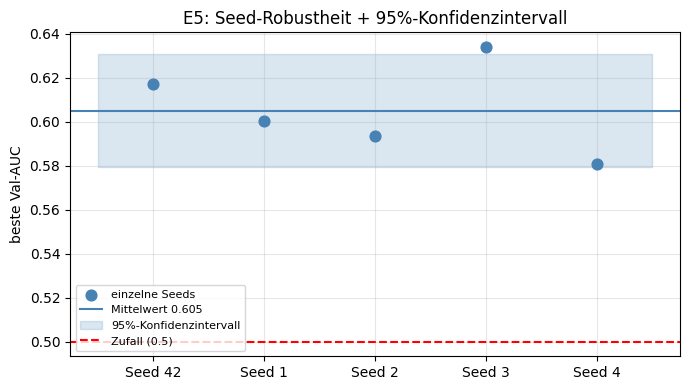

In [21]:
# E5 - Seed-Robustheit und Konfidenzintervall
# Wir trainieren die E2-Konfiguration (alle Daten + pos_weight) mehrfach mit
# verschiedenen Seeds. Jeder Seed erzeugt einen anderen Patient-Split UND eine
# andere Modell-Initialisierung. Aus den besten Val-AUCs je Lauf berechnen wir
# Mittelwert, Streuung und ein 95%-Konfidenzintervall.

def e5_ein_durchlauf(seed, epochen=15):
    # Reproduzierbarkeit pro Seed
    """Trainiert die E2-Konfiguration einmal mit dem angegebenen Seed und gibt
    die beste Val-AUC dieses Laufs zurück."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Patient-Split mit diesem Seed
    pats = df_verfuegbar['patient_id'].unique().copy()
    rng = np.random.default_rng(seed)
    rng.shuffle(pats)
    nval = int(len(pats) * VAL_ANTEIL)
    valp = set(pats[:nval])
    d_val = df_verfuegbar[df_verfuegbar['patient_id'].isin(valp)]
    d_tr  = df_verfuegbar[~df_verfuegbar['patient_id'].isin(valp)]

    npos = int((d_tr['cancer'] == 1).sum())
    nneg = int((d_tr['cancer'] == 0).sum())
    pw = torch.tensor([nneg / npos], dtype=torch.float32, device=DEVICE)

    tr = MammografieDataset(d_tr,  BILDER_ORDNER, train_transforms_3kanal, fuer_resnet18=True)
    va = MammografieDataset(d_val, BILDER_ORDNER, val_transforms_3kanal,   fuer_resnet18=True)
    ltr = DataLoader(tr, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=torch.cuda.is_available())
    lva = DataLoader(va, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

    # ResNet18 mit Logit-Ausgabe, letzter Block aufgetaut
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for p in m.parameters():
        p.requires_grad = False
    for p in m.layer4[1].parameters():
        p.requires_grad = True
    m.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(m.fc.in_features, 1))
    m = m.to(DEVICE)

    krit = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt = optim.Adam(filter(lambda p: p.requires_grad, m.parameters()), lr=1e-4, weight_decay=1e-4)

    beste = 0.0
    for ep in range(epochen):
        trainiere_eine_epoche(m, ltr, opt, krit)
        _, labs_s, preds_s = validiere(m, lva, krit)
        fpr, tpr, _ = roc_curve(labs_s, preds_s)
        beste = max(beste, auc(fpr, tpr))
    return beste


seeds = [42, 1, 2, 3, 4]
e5_aucs = []
print('E5 - Seed-Robustheit (jeweils beste Val-AUC über 15 Epochen):')
for s in seeds:
    a = e5_ein_durchlauf(s, epochen=15)
    e5_aucs.append(a)
    print(f'  Seed {s:>2}: AUC {a:.4f}', flush=True)

e5_aucs = np.array(e5_aucs)
n = len(e5_aucs)
mw = e5_aucs.mean()
sd = e5_aucs.std(ddof=1)

# 95%-Konfidenzintervall (t-Verteilung; fällt auf Normalapprox zurück, falls scipy fehlt)
try:
    from scipy import stats
    tkrit = stats.t.ppf(0.975, df=n - 1)
except Exception:
    tkrit = 1.96
halb = tkrit * sd / np.sqrt(n)
ci_low, ci_high = mw - halb, mw + halb

print(f'\nMittelwert AUC:      {mw:.4f}')
print(f'Standardabweichung:  {sd:.4f}')
print(f'95%-Konfidenzintervall: [{ci_low:.4f}, {ci_high:.4f}]')
if ci_low <= 0.5 <= ci_high:
    print('FAZIT: 0.5 liegt IM Intervall -> statistisch NICHT von Zufall unterscheidbar.')
else:
    print('FAZIT: 0.5 liegt ausserhalb -> Modell ist signifikant besser als Zufall.')

# Plot
plt.figure(figsize=(7, 4))
plt.scatter(range(1, n + 1), e5_aucs, s=60, zorder=3, color='steelblue', label='einzelne Seeds')
plt.axhline(mw, color='steelblue', label=f'Mittelwert {mw:.3f}')
plt.fill_between([0.5, n + 0.5], ci_low, ci_high, alpha=0.2, color='steelblue', label='95%-Konfidenzintervall')
plt.axhline(0.5, color='red', ls='--', label='Zufall (0.5)')
plt.xticks(range(1, n + 1), [f'Seed {s}' for s in seeds])
plt.ylabel('beste Val-AUC')
plt.title('E5: Seed-Robustheit + 95%-Konfidenzintervall')
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 17. E1 - Auflösung 512 px

Testet den letzten großen Hebel: höhere Auflösung. Krebszeichen wie kleine
Massen oder Verkalkungen sind winzig und gehen beim Herunterskalieren verloren.
Ich trainiere die E2-Konfiguration bei 512 px und vergleiche sie gegen eine
384-px-Baseline, die in derselben Zelle mit exakt identischem Setup neu
trainiert wird (gleicher Patient-Split, gleicher Seed, gleiche Batchgröße,
gleiche Epochenzahl). Nur die Auflösung unterscheidet sich, die AUC-Differenz
ist damit sauber darauf zurückführbar (gepaarter Vergleich).


In [22]:
# E1 - Auflösung 512 px (sauberer gepaarter Vergleich gegen 384 px)
# Wichtig: Um eine echte Ein-Variablen-Ablation zu haben, wird die 384px-Baseline
# hier mit EXAKT demselben Setup neu trainiert (gleicher Split, gleicher Seed,
# gleiche Batchgröße E1_BATCH, gleiche Epochen). Nur die Auflösung
# unterscheidet sich. Früher wurde als Baseline der E5-Wert (Batch 16)
# herangezogen - das war ein zweiter, unsauberer Einflussfaktor.
import pickle

E1_SEED    = 42     # gleicher Seed wie E5 -> identischer Split
E1_GROESSE = 512
E1_BATCH   = 8      # kleiner wegen 4 GB VRAM; bei "CUDA out of memory" auf 4 senken
E1_EPOCHEN = 15


def _e1_baue_modell():
    """ResNet18, Logit-Ausgabe, nur layer4[1] aufgetaut - identisch zu E2/E5."""
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for p in m.parameters():
        p.requires_grad = False
    for p in m.layer4[1].parameters():
        p.requires_grad = True
    m.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(m.fc.in_features, 1))
    return m.to(DEVICE)


def _e1_trainiere(ld_tr, ld_va, pos_weight, epochen):
    """Trainiert ein frisches Modell und gibt die beste Val-AUC zurück."""
    m = _e1_baue_modell()
    krit = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = optim.Adam(filter(lambda p: p.requires_grad, m.parameters()), lr=1e-4, weight_decay=1e-4)
    beste = 0.0
    for ep in range(epochen):
        tl = trainiere_eine_epoche(m, ld_tr, opt, krit)
        _, labs_e, preds_e = validiere(m, ld_va, krit)
        fpr, tpr, _ = roc_curve(labs_e, preds_e)
        a = auc(fpr, tpr)
        beste = max(beste, a)
        print(f'    Epoche {ep+1:>2}/{epochen} | Train {tl:.4f} | AUC {a:.4f}', flush=True)
    return beste


# 1) 512px-Cache aufbauen (einmalig, mit Disk-Persistenz)
cache512_datei = f'bild_cache_{E1_GROESSE}.pkl'
if os.path.exists(cache512_datei):
    print(f'Lade 512px-Cache aus {cache512_datei}...', flush=True)
    with open(cache512_datei, 'rb') as f:
        cache512 = pickle.load(f)
else:
    print('Baue 512px-Cache (decodiere alle DICOMs neu bei 512px, einmalig)...', flush=True)
    cache512 = {}
    for _, z in df_verfuegbar.iterrows():
        pfad = f"{BILDER_ORDNER}/{z['patient_id']}/{z['image_id']}.dcm"
        cache512[pfad] = lade_und_verarbeite_dicom(pfad, zielgroesse=E1_GROESSE)
        if len(cache512) % 100 == 0:
            print(f'  {len(cache512)}/{len(df_verfuegbar)} Bilder...', flush=True)
    with open(cache512_datei, 'wb') as f:
        pickle.dump(cache512, f)
    print(f'512px-Cache fertig: {len(cache512)} Bilder, gespeichert in {cache512_datei}.', flush=True)

# 2) Mini-Dataset, das aus dem 512px-Cache liest (3 Kanäle für ResNet)
class E1Dataset(Dataset):
    def __init__(self, dataframe, cache, transform):
        self.df = dataframe.reset_index(drop=True)
        self.cache = cache
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        z = self.df.iloc[idx]
        pfad = f"{BILDER_ORDNER}/{z['patient_id']}/{z['image_id']}.dcm"
        label = torch.tensor(z['cancer'], dtype=torch.float32)
        bild = np.stack([self.cache[pfad]] * 3, axis=-1)
        return self.transform(bild), label, 0   # drittes Element = Dummy-Meta

# 3) Patient-Split mit Seed 42 (identisch zu E5 Seed 42)
torch.manual_seed(E1_SEED)
np.random.seed(E1_SEED)
pats = df_verfuegbar['patient_id'].unique().copy()
rng = np.random.default_rng(E1_SEED)
rng.shuffle(pats)
nval = int(len(pats) * VAL_ANTEIL)
valp = set(pats[:nval])
d_val = df_verfuegbar[df_verfuegbar['patient_id'].isin(valp)]
d_tr  = df_verfuegbar[~df_verfuegbar['patient_id'].isin(valp)]
npos = int((d_tr['cancer'] == 1).sum())
nneg = int((d_tr['cancer'] == 0).sum())
pw = torch.tensor([nneg / npos], dtype=torch.float32, device=DEVICE)
print(f'Train: {len(d_tr)} | Val: {len(d_val)} | pos_weight = {nneg/npos:.2f}')

# 4) Training bei 512px
ds_tr = E1Dataset(d_tr,  cache512, train_transforms_3kanal)
ds_va = E1Dataset(d_val, cache512, val_transforms_3kanal)
ld_tr = DataLoader(ds_tr, batch_size=E1_BATCH, shuffle=True,  num_workers=0, pin_memory=torch.cuda.is_available())
ld_va = DataLoader(ds_va, batch_size=E1_BATCH, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print(f'\nE1 Training bei {E1_GROESSE}px (Seed {E1_SEED}, Batch {E1_BATCH}):')
torch.manual_seed(E1_SEED)
np.random.seed(E1_SEED)
e1_beste = _e1_trainiere(ld_tr, ld_va, pw, E1_EPOCHEN)

# 5) Gepaarte 384px-Baseline: identisches Setup, nur andere Auflösung.
#    Liest aus dem vorhandenen 384px-Cache (bild_cache) über MammografieDataset.
ds_tr_384 = MammografieDataset(d_tr,  BILDER_ORDNER, train_transforms_3kanal, fuer_resnet18=True)
ds_va_384 = MammografieDataset(d_val, BILDER_ORDNER, val_transforms_3kanal,   fuer_resnet18=True)
ld_tr_384 = DataLoader(ds_tr_384, batch_size=E1_BATCH, shuffle=True,  num_workers=0, pin_memory=torch.cuda.is_available())
ld_va_384 = DataLoader(ds_va_384, batch_size=E1_BATCH, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print(f'\n384px-Baseline (identisches Setup, Batch {E1_BATCH}, Seed {E1_SEED}):')
torch.manual_seed(E1_SEED)
np.random.seed(E1_SEED)
baseline_384 = _e1_trainiere(ld_tr_384, ld_va_384, pw, E1_EPOCHEN)

# 6) Vergleich
print(f'\nE1 beste Val-AUC bei 512px: {e1_beste:.4f}')
print(f'Baseline 384px (gleiches Setup): {baseline_384:.4f}')
print(f'Differenz (512 - 384): {e1_beste - baseline_384:+.4f}')
if e1_beste - baseline_384 > 0.02:
    print('-> 512px bringt eine spürbare Verbesserung. Mit mehreren Seeds bestätigen.')
elif e1_beste - baseline_384 < -0.02:
    print('-> 512px ist schlechter. Höhere Auflösung hilft hier nicht.')
else:
    print('-> Kein klarer Unterschied. Auflösung ist nicht der entscheidende Hebel.')

Lade 512px-Cache aus bild_cache_512.pkl...
Train: 1869 | Val: 447 | pos_weight = 0.98

E1 Training bei 512px (Seed 42, Batch 8):
    Epoche  1/15 | Train 0.7247 | AUC 0.5672
    Epoche  2/15 | Train 0.6963 | AUC 0.5647
    Epoche  3/15 | Train 0.6964 | AUC 0.5937
    Epoche  4/15 | Train 0.6855 | AUC 0.5811
    Epoche  5/15 | Train 0.6781 | AUC 0.6063
    Epoche  6/15 | Train 0.6546 | AUC 0.5883
    Epoche  7/15 | Train 0.6696 | AUC 0.6304
    Epoche  8/15 | Train 0.6698 | AUC 0.6030
    Epoche  9/15 | Train 0.6505 | AUC 0.5876
    Epoche 10/15 | Train 0.6418 | AUC 0.6191
    Epoche 11/15 | Train 0.6332 | AUC 0.6210
    Epoche 12/15 | Train 0.6368 | AUC 0.6212
    Epoche 13/15 | Train 0.6336 | AUC 0.6381
    Epoche 14/15 | Train 0.6347 | AUC 0.6245
    Epoche 15/15 | Train 0.6163 | AUC 0.6285

384px-Baseline (identisches Setup, Batch 8, Seed 42):
    Epoche  1/15 | Train 0.7294 | AUC 0.5856
    Epoche  2/15 | Train 0.6959 | AUC 0.5648
    Epoche  3/15 | Train 0.7023 | AUC 0.5938
    Ep

## 18. Weitere Untersuchungen (E4, E3, E6)

Schließt die offenen Punkte des Untersuchungsplans ab:
- E4: Welche Lernrate ist die beste?
- E3: Wie tief sollte das ResNet aufgetaut werden?
- E6: Wie stark verfälscht ein Bild-Split (Data Leakage) das Ergebnis?
Alle nutzen die E2-Konfiguration (alle Daten + pos_weight) bei 384 px, Seed 42,
sodass die Ergebnisse direkt vergleichbar sind.


In [23]:
# Gemeinsame Hilfsfunktion für E4, E3 und E6.
# Trainiert die E2-Konfiguration mit wählbaren Parametern und gibt die beste
# Val-AUC zurück. Nutzt den vorhandenen 384px-Cache (bild_cache).

def trainiere_e2_variante(seed=42, lr=1e-4, epochen=15,
                          aufbau='layer4', split='patient', batch=BATCH_SIZE):
    # aufbau: 'fc' (nur Kopf) | 'layer4' | 'layer3_4'
    # split:  'patient' (kein Leakage) | 'bild' (mit Leakage)
    """Trainiert die E2-Konfiguration mit wählbarer Auftau-Tiefe, Lernrate und
    Split-Art. Gibt die beste Val-AUC zurück. Basis für E3, E4 und E6."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Aufteilung
    if split == 'patient':
        einheiten = df_verfuegbar['patient_id'].unique().copy()
        rng = np.random.default_rng(seed)
        rng.shuffle(einheiten)
        nval = int(len(einheiten) * VAL_ANTEIL)
        valset = set(einheiten[:nval])
        d_val = df_verfuegbar[df_verfuegbar['patient_id'].isin(valset)]
        d_tr  = df_verfuegbar[~df_verfuegbar['patient_id'].isin(valset)]
    else:  # bild-level (mischt Bilder, Patienten landen in Train UND Val)
        idx = df_verfuegbar.sample(frac=1, random_state=seed).index
        nval = int(len(idx) * VAL_ANTEIL)
        d_val = df_verfuegbar.loc[idx[:nval]]
        d_tr  = df_verfuegbar.loc[idx[nval:]]

    npos = int((d_tr['cancer'] == 1).sum())
    nneg = int((d_tr['cancer'] == 0).sum())
    pw = torch.tensor([nneg / npos], dtype=torch.float32, device=DEVICE)

    tr = MammografieDataset(d_tr,  BILDER_ORDNER, train_transforms_3kanal, fuer_resnet18=True)
    va = MammografieDataset(d_val, BILDER_ORDNER, val_transforms_3kanal,   fuer_resnet18=True)
    ltr = DataLoader(tr, batch_size=batch, shuffle=True,  num_workers=0, pin_memory=torch.cuda.is_available())
    lva = DataLoader(va, batch_size=batch, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

    # Modell mit wählbarer Auftau-Tiefe
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for p in m.parameters():
        p.requires_grad = False
    if aufbau == 'layer4':
        for p in m.layer4[1].parameters():
            p.requires_grad = True
    elif aufbau == 'layer3_4':
        for p in m.layer3.parameters():
            p.requires_grad = True
        for p in m.layer4.parameters():
            p.requires_grad = True
    # bei aufbau == 'fc' bleibt der Backbone komplett eingefroren
    m.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(m.fc.in_features, 1))
    m = m.to(DEVICE)

    krit = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt = optim.Adam(filter(lambda p: p.requires_grad, m.parameters()), lr=lr, weight_decay=1e-4)

    beste = 0.0
    for ep in range(epochen):
        trainiere_eine_epoche(m, ltr, opt, krit)
        _, labs_v, preds_v = validiere(m, lva, krit)
        fpr, tpr, _ = roc_curve(labs_v, preds_v)
        beste = max(beste, auc(fpr, tpr))
    return beste

print('Hilfsfunktion trainiere_e2_variante bereit.')


Hilfsfunktion trainiere_e2_variante bereit.


E4 - Lernraten-Vergleich (E2-Konfig, Seed 42, 15 Epochen):
  LR 1e-03: beste Val-AUC 0.6282
  LR 3e-04: beste Val-AUC 0.6341
  LR 1e-04: beste Val-AUC 0.6172
  LR 3e-05: beste Val-AUC 0.6265

Beste Lernrate: 3e-04 (AUC 0.6341)


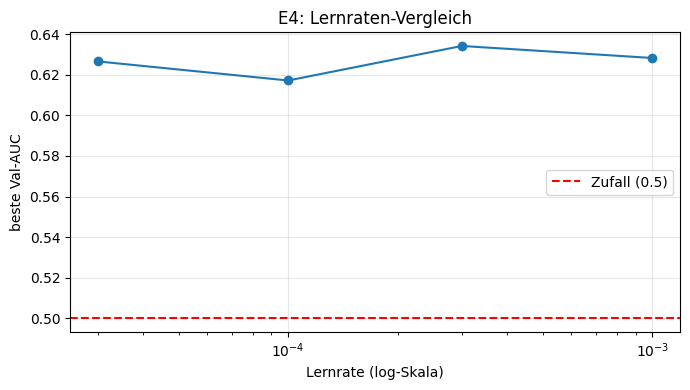

In [24]:
# E4 - Lernraten-Vergleich
#Wie wurden die Hyperparameter (speziell die Lernrate) gewählt?
# Gleiche Konfiguration, nur die Lernrate variiert.

print('E4 - Lernraten-Vergleich (E2-Konfig, Seed 42, 15 Epochen):')
e4_ergebnisse = {}
for lr in [1e-3, 3e-4, 1e-4, 3e-5]:
    a = trainiere_e2_variante(seed=42, lr=lr, epochen=15, aufbau='layer4', split='patient')
    e4_ergebnisse[lr] = a
    print(f'  LR {lr:.0e}: beste Val-AUC {a:.4f}', flush=True)

best_lr = max(e4_ergebnisse, key=e4_ergebnisse.get)
print(f'\nBeste Lernrate: {best_lr:.0e} (AUC {e4_ergebnisse[best_lr]:.4f})')

plt.figure(figsize=(7, 4))
lrs = list(e4_ergebnisse.keys())
aucs = [e4_ergebnisse[l] for l in lrs]
plt.semilogx(lrs, aucs, marker='o')
plt.axhline(0.5, color='red', ls='--', label='Zufall (0.5)')
plt.xlabel('Lernrate (log-Skala)'); plt.ylabel('beste Val-AUC')
plt.title('E4: Lernraten-Vergleich'); plt.legend()
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


E3 - Auftau-Tiefe (E2-Konfig, Seed 42, LR 1e-4, 15 Epochen):
  fc       : beste Val-AUC 0.5562
  layer4   : beste Val-AUC 0.6314
  layer3_4 : beste Val-AUC 0.6752


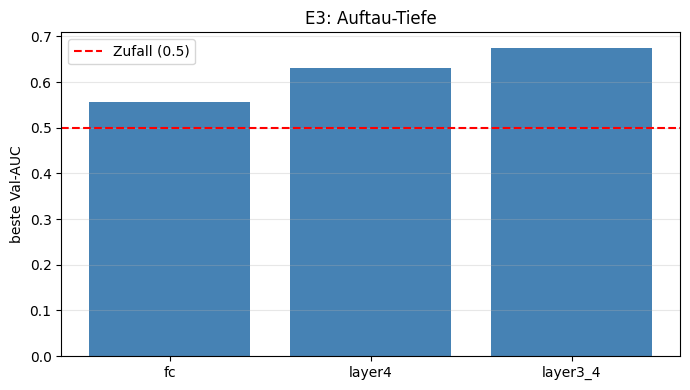

In [25]:

# E3 - Auftau-Tiefe des ResNet
#Wie tief sollte fine-getunt werden? Nur der Kopf, der letzte Block,
# oder layer3+layer4? Batch hier 8, weil layer3_4 mehr VRAM braucht.

print('E3 - Auftau-Tiefe (E2-Konfig, Seed 42, LR 1e-4, 15 Epochen):')
e3_ergebnisse = {}
for name in ['fc', 'layer4', 'layer3_4']:
    a = trainiere_e2_variante(seed=42, lr=1e-4, epochen=15, aufbau=name, split='patient', batch=8)
    e3_ergebnisse[name] = a
    print(f'  {name:9}: beste Val-AUC {a:.4f}', flush=True)

plt.figure(figsize=(7, 4))
namen = list(e3_ergebnisse.keys())
aucs = [e3_ergebnisse[n] for n in namen]
plt.bar(namen, aucs, color='steelblue')
plt.axhline(0.5, color='red', ls='--', label='Zufall (0.5)')
plt.ylabel('beste Val-AUC'); plt.title('E3: Auftau-Tiefe'); plt.legend()
plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()


In [26]:
# E6 - Bild-Split vs. Patient-Split (Data Leakage belegen)
# Zeigt empirisch, wie ein Split auf Bildebene (gleicher Patient in Train UND
# Val) die AUC verfälscht im Vergleich zum korrekten Patient-Split.

print('E6 - Bild-Split vs Patient-Split (E2-Konfig, Seed 42, 15 Epochen):')
auc_bild    = trainiere_e2_variante(seed=42, lr=1e-4, epochen=15, aufbau='layer4', split='bild')
auc_patient = trainiere_e2_variante(seed=42, lr=1e-4, epochen=15, aufbau='layer4', split='patient')
print(f'  Bild-Split    (mit Leakage):  AUC {auc_bild:.4f}')
print(f'  Patient-Split (ohne Leakage): AUC {auc_patient:.4f}')
print(f'  Differenz: {auc_bild - auc_patient:+.4f}')
if auc_bild > auc_patient + 0.01:
    print('-> Der Bild-Split liefert eine optimistischere AUC -> Data Leakage belegt.')
elif auc_bild < auc_patient - 0.01:
    print('-> Der Bild-Split ist schlechter (kann bei Rauschen vorkommen).')
else:
    print('-> Kein nennenswerter Unterschied in diesem einzelnen Lauf.')


E6 - Bild-Split vs Patient-Split (E2-Konfig, Seed 42, 15 Epochen):
  Bild-Split    (mit Leakage):  AUC 0.5790
  Patient-Split (ohne Leakage): AUC 0.6172
  Differenz: -0.0382
-> Der Bild-Split ist schlechter (kann bei Rauschen vorkommen).


## 19. E3 Absicherung (Seed-Robustheit der Auftau-Tiefe)

Bestätigt mit mehreren Seeds, ob layer3+4 robust besser ist als layer4, oder ob
der Unterschied im Rauschen liegt. Gepaarter Vergleich pro Seed mit
Konfidenzintervall der Differenz. Längstes Experiment (5 Seeds x 2 Varianten).


E3 Absicherung (5 Seeds, je 15 Epochen):
  Seed 42: layer4 0.6314 | layer3_4 0.6749
  Seed  1: layer4 0.5924 | layer3_4 0.7009
  Seed  2: layer4 0.5994 | layer3_4 0.7133
  Seed  3: layer4 0.6258 | layer3_4 0.6642
  Seed  4: layer4 0.5779 | layer3_4 0.6873

layer4: Mittel 0.6054 (Std 0.0226), 95%-KI [0.5773, 0.6335]
layer3_4: Mittel 0.6881 (Std 0.0196), 95%-KI [0.6637, 0.7125]

Differenz (layer3_4 - layer4): Mittel +0.0827, 95%-KI [+0.0353, +0.1302]
FAZIT: layer3_4 ist signifikant besser als layer4 (KI der Differenz > 0).


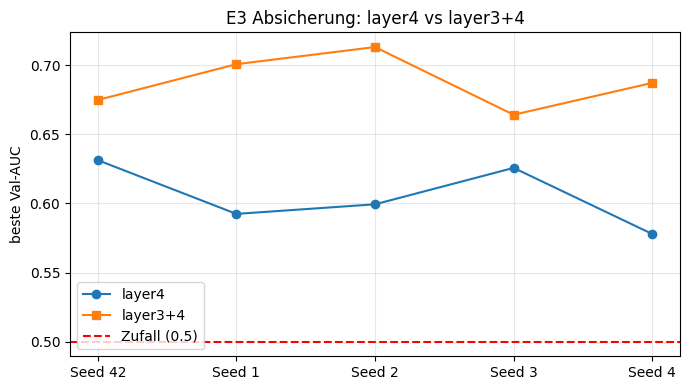

In [27]:
# E3 Absicherung - layer4 vs layer3_4 über mehrere Seeds
# Bei Zeitmangel e3b_seeds auf z.B. [42, 1, 2] kürzen.

e3b_seeds = [42, 1, 2, 3, 4]
e3b = {'layer4': [], 'layer3_4': []}
print('E3 Absicherung (5 Seeds, je 15 Epochen):')
for s in e3b_seeds:
    for aufbau in ['layer4', 'layer3_4']:
        a = trainiere_e2_variante(seed=s, lr=1e-4, epochen=15, aufbau=aufbau, split='patient', batch=8)
        e3b[aufbau].append(a)
    print(f'  Seed {s:>2}: layer4 {e3b["layer4"][-1]:.4f} | layer3_4 {e3b["layer3_4"][-1]:.4f}', flush=True)

def _ci(werte):
    werte = np.array(werte)
    n = len(werte)
    mw = werte.mean()
    sd = werte.std(ddof=1)
    try:
        from scipy import stats
        tk = stats.t.ppf(0.975, df=n - 1)
    except Exception:
        tk = 2.776
    h = tk * sd / np.sqrt(n)
    return mw, sd, mw - h, mw + h

print('')
for name in ['layer4', 'layer3_4']:
    mw, sd, lo, hi = _ci(e3b[name])
    print(f'{name}: Mittel {mw:.4f} (Std {sd:.4f}), 95%-KI [{lo:.4f}, {hi:.4f}]')

diff = np.array(e3b['layer3_4']) - np.array(e3b['layer4'])
mwd, sdd, lod, hid = _ci(diff)
print('')
print(f'Differenz (layer3_4 - layer4): Mittel {mwd:+.4f}, 95%-KI [{lod:+.4f}, {hid:+.4f}]')
if lod > 0:
    print('FAZIT: layer3_4 ist signifikant besser als layer4 (KI der Differenz > 0).')
else:
    print('FAZIT: Kein signifikanter Unterschied (KI der Differenz schließt 0 ein).')

plt.figure(figsize=(7, 4))
x = np.arange(len(e3b_seeds))
plt.plot(x, e3b['layer4'], marker='o', label='layer4')
plt.plot(x, e3b['layer3_4'], marker='s', label='layer3+4')
plt.axhline(0.5, color='red', ls='--', label='Zufall (0.5)')
plt.xticks(x, [f'Seed {s}' for s in e3b_seeds])
plt.ylabel('beste Val-AUC')
plt.title('E3 Absicherung: layer4 vs layer3+4')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 20. E7 - Lernkurve (Performance vs. Trainingsdatenmenge)

Bringt mehr Trainingsdaten mehr Leistung? Das beste Setup (layer3+4, alle Daten
+ pos_weight) wird auf wachsenden Anteilen der Trainingsdaten trainiert, bei
fester Validierungsmenge, damit die AUC-Unterschiede nur von der Trainingsgröße
kommen. Steigt die Kurve nach rechts, würde zusätzliches Datenmaterial die
Leistung weiter verbessern.


E7 - Lernkurve (Trainingsgröße variiert, Validierung fest):
Feste Validierung: 447 Bilder
   25% | Trainingsbilder  437 (Krebs 207) | beste Val-AUC 0.5634
   50% | Trainingsbilder  932 (Krebs 476) | beste Val-AUC 0.6122
   75% | Trainingsbilder 1412 (Krebs 709) | beste Val-AUC 0.6246
  100% | Trainingsbilder 1869 (Krebs 945) | beste Val-AUC 0.6635


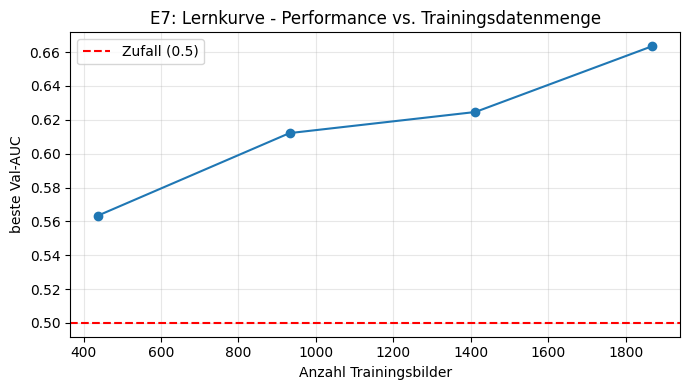

In [28]:
# E7 - Lernkurve: Performance vs. Trainingsdatenmenge
# Fester Patient-Split (Seed 42), feste Validierung. 
#Nur die Trainingsgröße wird variiert (25% / 50% / 75% / 100% der Trainings-Patienten).

torch.manual_seed(42)
np.random.seed(42)

# Patient-Split: feste Validierung, restliche Patienten sind der Trainings-Pool
patienten_lk = df_verfuegbar['patient_id'].unique().copy()
rng_lk = np.random.default_rng(42)
rng_lk.shuffle(patienten_lk)
n_val_lk = int(len(patienten_lk) * VAL_ANTEIL)
val_pat_lk = set(patienten_lk[:n_val_lk])
df_val_lk  = df_verfuegbar[df_verfuegbar['patient_id'].isin(val_pat_lk)]
train_pool = df_verfuegbar[~df_verfuegbar['patient_id'].isin(val_pat_lk)]

# feste Validierung (ändert sich über alle Trainingsgrößen NICHT)
ds_va_lk = MammografieDataset(df_val_lk, BILDER_ORDNER, val_transforms_3kanal, fuer_resnet18=True)
ld_va_lk = DataLoader(ds_va_lk, batch_size=8, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

# Trainings-Patienten mischen, damit die Teilmengen sinnvoll geschachtelt sind
train_pats = train_pool['patient_id'].unique().copy()
rng_lk2 = np.random.default_rng(42)
rng_lk2.shuffle(train_pats)

anteile = [0.25, 0.5, 0.75, 1.0]
lernkurve = []
print('E7 - Lernkurve (Trainingsgröße variiert, Validierung fest):')
print(f'Feste Validierung: {len(df_val_lk)} Bilder')

for anteil in anteile:
    n_take = max(1, int(len(train_pats) * anteil))
    take_pats = set(train_pats[:n_take])
    df_tr_sub = train_pool[train_pool['patient_id'].isin(take_pats)]

    npos = int((df_tr_sub['cancer'] == 1).sum())
    nneg = int((df_tr_sub['cancer'] == 0).sum())
    if npos == 0 or nneg == 0:
        print(f'  Anteil {anteil:.0%}: übersprungen (Klasse fehlt)')
        continue
    pw = torch.tensor([nneg / npos], dtype=torch.float32, device=DEVICE)

    ds_tr_lk = MammografieDataset(df_tr_sub, BILDER_ORDNER, train_transforms_3kanal, fuer_resnet18=True)
    ld_tr_lk = DataLoader(ds_tr_lk, batch_size=8, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())

    # bestes Setup aus E3: layer3 + layer4 auftauen
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for p in m.parameters():
        p.requires_grad = False
    for p in m.layer3.parameters():
        p.requires_grad = True
    for p in m.layer4.parameters():
        p.requires_grad = True
    m.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(m.fc.in_features, 1))
    m = m.to(DEVICE)
    krit = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt = optim.Adam(filter(lambda p: p.requires_grad, m.parameters()), lr=1e-4, weight_decay=1e-4)

    beste = 0.0
    for ep in range(15):
        trainiere_eine_epoche(m, ld_tr_lk, opt, krit)
        _, labs_lk, preds_lk = validiere(m, ld_va_lk, krit)
        fpr, tpr, _ = roc_curve(labs_lk, preds_lk)
        beste = max(beste, auc(fpr, tpr))
    lernkurve.append((len(df_tr_sub), beste))
    print(f'  {anteil:>4.0%} | Trainingsbilder {len(df_tr_sub):>4} (Krebs {npos}) | beste Val-AUC {beste:.4f}', flush=True)

# Plot
groessen = [g for g, a in lernkurve]
aucs = [a for g, a in lernkurve]
plt.figure(figsize=(7, 4))
plt.plot(groessen, aucs, marker='o')
plt.axhline(0.5, color='red', ls='--', label='Zufall (0.5)')
plt.xlabel('Anzahl Trainingsbilder')
plt.ylabel('beste Val-AUC')
plt.title('E7: Lernkurve - Performance vs. Trainingsdatenmenge')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

#print('')
#print('Interpretation: Steigt die Kurve nach rechts an, würde zusätzliches')
#print('Datenmaterial die Leistung voraussichtlich weiter verbessern.')


## 21. Finales Modell - konkrete Tumor Ja/Nein Klassifikation

Bisher wurden vor allem AUC-Werte und Lernkurven berichtet (schwellenunabhängige
Kennzahlen). Hier wird das beste gefundene Setup (layer3+layer4 aufgetaut, alle
Daten + pos_weight) einmal vollständig trainiert und konkret als binäre
Klassifikation ausgewertet: Confusion Matrix, Accuracy, Precision/Recall UND
einzelne Beispielvorhersagen (Tumor: Ja/Nein je Bild). Das macht sichtbar, dass
das Modell tatsächlich eine Ja/Nein-Entscheidung trifft und wie stark die
begrenzte Datenmenge deren Zuverlässigkeit einschränkt.


In [29]:
# Finales Modell trainieren (bestes Setup: layer3+layer4, alle Daten)
torch.manual_seed(42)
np.random.seed(42)

patienten_fin = df_verfuegbar['patient_id'].unique().copy()
rng_fin = np.random.default_rng(42)
rng_fin.shuffle(patienten_fin)
n_val_fin = int(len(patienten_fin) * VAL_ANTEIL)
val_pat_fin = set(patienten_fin[:n_val_fin])
df_val_fin = df_verfuegbar[df_verfuegbar['patient_id'].isin(val_pat_fin)]
df_tr_fin  = df_verfuegbar[~df_verfuegbar['patient_id'].isin(val_pat_fin)]

npos = int((df_tr_fin['cancer'] == 1).sum())
nneg = int((df_tr_fin['cancer'] == 0).sum())
pw_fin = torch.tensor([nneg / npos], dtype=torch.float32, device=DEVICE)
print(f'Finales Modell - Train: {len(df_tr_fin)} (Krebs {npos}) | Val: {len(df_val_fin)}')

ds_tr_fin = MammografieDataset(df_tr_fin, BILDER_ORDNER, train_transforms_3kanal, fuer_resnet18=True)
ds_va_fin = MammografieDataset(df_val_fin, BILDER_ORDNER, val_transforms_3kanal, fuer_resnet18=True)
ld_tr_fin = DataLoader(ds_tr_fin, batch_size=8, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
ld_va_fin = DataLoader(ds_va_fin, batch_size=8, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

modell_final = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for p in modell_final.parameters():
    p.requires_grad = False
for p in modell_final.layer3.parameters():
    p.requires_grad = True
for p in modell_final.layer4.parameters():
    p.requires_grad = True
modell_final.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(modell_final.fc.in_features, 1))
modell_final = modell_final.to(DEVICE)

kriterium_fin = nn.BCEWithLogitsLoss(pos_weight=pw_fin)
optim_fin = optim.Adam(filter(lambda p: p.requires_grad, modell_final.parameters()), lr=3e-4, weight_decay=1e-4)
scheduler_fin = optim.lr_scheduler.ReduceLROnPlateau(optim_fin, mode='max', factor=0.5, patience=4)

FINAL_PFAD = 'modell_final_beste.pth'
bester_fin_auc = 0.0
print('\nTraining finales Modell (20 Epochen):')
for ep in range(20):
    tl = trainiere_eine_epoche(modell_final, ld_tr_fin, optim_fin, kriterium_fin)
    _, labs_fin, preds_fin = validiere(modell_final, ld_va_fin, kriterium_fin)
    fpr, tpr, _ = roc_curve(labs_fin, preds_fin)
    a = auc(fpr, tpr)
    scheduler_fin.step(a)
    if a > bester_fin_auc:
        bester_fin_auc = a
        torch.save(modell_final.state_dict(), FINAL_PFAD)
        marker = '  *bestes*'
    else:
        marker = ''
    print(f'  Epoche {ep+1:>2}/20 | Train {tl:.4f} | AUC {a:.4f}{marker}', flush=True)

print(f'\nBeste Val-AUC: {bester_fin_auc:.4f} (gespeichert in {FINAL_PFAD})')


Finales Modell - Train: 1869 (Krebs 945) | Val: 447

Training finales Modell (20 Epochen):
  Epoche  1/20 | Train 0.7231 | AUC 0.5285  *bestes*
  Epoche  2/20 | Train 0.6981 | AUC 0.5181
  Epoche  3/20 | Train 0.7023 | AUC 0.5691  *bestes*
  Epoche  4/20 | Train 0.6982 | AUC 0.4873
  Epoche  5/20 | Train 0.6954 | AUC 0.5540
  Epoche  6/20 | Train 0.6860 | AUC 0.5635
  Epoche  7/20 | Train 0.6946 | AUC 0.5818  *bestes*
  Epoche  8/20 | Train 0.6932 | AUC 0.5198
  Epoche  9/20 | Train 0.6867 | AUC 0.5722
  Epoche 10/20 | Train 0.6797 | AUC 0.5929  *bestes*
  Epoche 11/20 | Train 0.6740 | AUC 0.5642
  Epoche 12/20 | Train 0.6824 | AUC 0.5689
  Epoche 13/20 | Train 0.6673 | AUC 0.6098  *bestes*
  Epoche 14/20 | Train 0.6704 | AUC 0.6414  *bestes*
  Epoche 15/20 | Train 0.6563 | AUC 0.6317
  Epoche 16/20 | Train 0.6610 | AUC 0.6437  *bestes*
  Epoche 17/20 | Train 0.6604 | AUC 0.6521  *bestes*
  Epoche 18/20 | Train 0.6412 | AUC 0.6580  *bestes*
  Epoche 19/20 | Train 0.6489 | AUC 0.6299
  

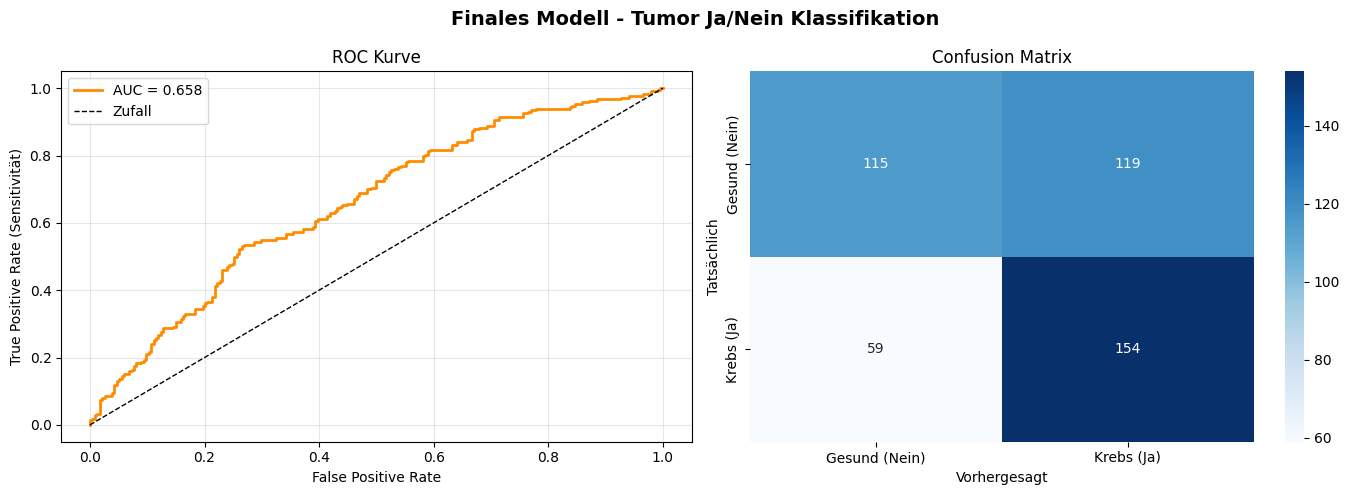

AUC: 0.6580
Accuracy: 0.6018
               precision    recall  f1-score   support

Gesund (Nein)       0.66      0.49      0.56       234
   Krebs (Ja)       0.56      0.72      0.63       213

     accuracy                           0.60       447
    macro avg       0.61      0.61      0.60       447
 weighted avg       0.61      0.60      0.60       447

Interpretation: Selbst mit dem besten gefundenen Setup bleibt die
Tumor-Ja/Nein-Klassifikation bei der begrenzten Anzahl an Krebs-
Trainingsbildern fehleranfällig. Das unterstreicht, dass die
Datenmenge nicht die Modellwahl der limitierende Faktor ist.

Beispielvorhersagen (Tumor: Ja/Nein) für einzelne Bilder:
  Patient 47724: tatsächlich Tumor: Nein | Modell sagt: Tumor: Nein ( 5.5% Wahrscheinlichkeit)  [richtig]
  Patient 59322: tatsächlich Tumor: Ja   | Modell sagt: Tumor: Ja   (54.7% Wahrscheinlichkeit)  [richtig]
  Patient 24947: tatsächlich Tumor: Ja   | Modell sagt: Tumor: Ja   (82.1% Wahrscheinlichkeit)  [richtig]
  Patien

In [37]:
# Konkrete Klassifikation: Tumor Ja / Nein (bestes Modell)
# Wichtig: das Modell gibt rohe Logits aus (kein Sigmoid als letzte Schicht,
# wegen BCEWithLogitsLoss). Für die Ja/Nein-Entscheidung wird hier explizit
# torch.sigmoid angewendet, um echte Wahrscheinlichkeiten (0-1) zu erhalten.

modell_final.load_state_dict(torch.load(FINAL_PFAD, map_location=DEVICE, weights_only=True))
modell_final.eval()

alle_labels, alle_wahrsch, alle_meta = [], [], []
with torch.no_grad():
    for bilder, labels, meta in ld_va_fin:
        logits = modell_final(bilder.to(DEVICE))
        wahrsch = torch.sigmoid(logits).cpu().numpy().flatten()
        alle_labels.extend(labels.numpy())
        alle_wahrsch.extend(wahrsch)
        for i in range(len(labels)):
            alle_meta.append({k: (v[i].item() if hasattr(v[i], 'item') else v[i]) for k, v in meta.items()})

alle_labels  = np.array(alle_labels)
alle_wahrsch = np.array(alle_wahrsch)
alle_klassen = (alle_wahrsch >= 0.5).astype(int)

fpr, tpr, _ = roc_curve(alle_labels, alle_wahrsch)
roc_auc = auc(fpr, tpr)
cm = confusion_matrix(alle_labels, alle_klassen)

fig, achsen = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Finales Modell - Tumor Ja/Nein Klassifikation', fontsize=14, fontweight='bold')

achsen[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
achsen[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Zufall')
achsen[0].set_xlabel('False Positive Rate')
achsen[0].set_ylabel('True Positive Rate (Sensitivität)')
achsen[0].set_title('ROC Kurve')
achsen[0].legend(); achsen[0].grid(alpha=0.3)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=achsen[1],
            xticklabels=['Gesund (Nein)', 'Krebs (Ja)'],
            yticklabels=['Gesund (Nein)', 'Krebs (Ja)'])
achsen[1].set_xlabel('Vorhergesagt')
achsen[1].set_ylabel('Tatsächlich')
achsen[1].set_title('Confusion Matrix')

plt.tight_layout(); plt.show()

print(f'AUC: {roc_auc:.4f}')
print(f'Accuracy: {(alle_klassen == alle_labels).mean():.4f}')
print(classification_report(alle_labels, alle_klassen,
                            target_names=['Gesund (Nein)', 'Krebs (Ja)'],
                            zero_division=0))

print('Interpretation: Selbst mit dem besten gefundenen Setup bleibt die')
print('Tumor-Ja/Nein-Klassifikation bei der begrenzten Anzahl an Krebs-')
print('Trainingsbildern fehleranfällig. Das unterstreicht, dass die')
print('Datenmenge nicht die Modellwahl der limitierende Faktor ist.')

# Konkrete Beispielvorhersagen, damit sichtbar wird, WIE das Modell entscheidet
print('\nBeispielvorhersagen (Tumor: Ja/Nein) für einzelne Bilder:')
idx_beispiele = np.random.RandomState(42).choice(len(alle_labels), size=10, replace=False)
for idx in idx_beispiele:
    tats  = 'Ja' if alle_labels[idx] == 1 else 'Nein'
    vorh  = 'Ja' if alle_klassen[idx] == 1 else 'Nein'
    ok    = 'richtig' if tats == vorh else 'FALSCH'
    print(f'  Patient {alle_meta[idx]["patient_id"]}: tatsächlich Tumor: {tats:<4} | '
          f'Modell sagt: Tumor: {vorh:<4} ({alle_wahrsch[idx]*100:4.1f}% Wahrscheinlichkeit)  [{ok}]')


## 22. Grad-CAM - wo im Bild schaut das Modell hin?

Ergänzt die Ja/Nein-Klassifikation um eine Heatmap-Visualisierung mittels
Grad-CAM (Gradient-weighted Class Activation Mapping). Sie zeigt, welche
Bildregionen die Entscheidung des Modells am stärksten beeinflusst haben.

Das Modell wurde nur mit Bild-Ebene-Labels (Tumor Ja/Nein
für das gesamte Bild) trainiert, nicht mit Positions-Labels - der RSNA-
Datensatz enthält dafür keine Ground-Truth-Boxen. Grad-CAM zeigt daher, worauf
das Modell bei seiner Entscheidung achtet, nicht zwingend die exakte
Tumorposition. Es ist ein Interpretierbarkeits-Werkzeug, keine validierte
Lokalisierung/Segmentierung.


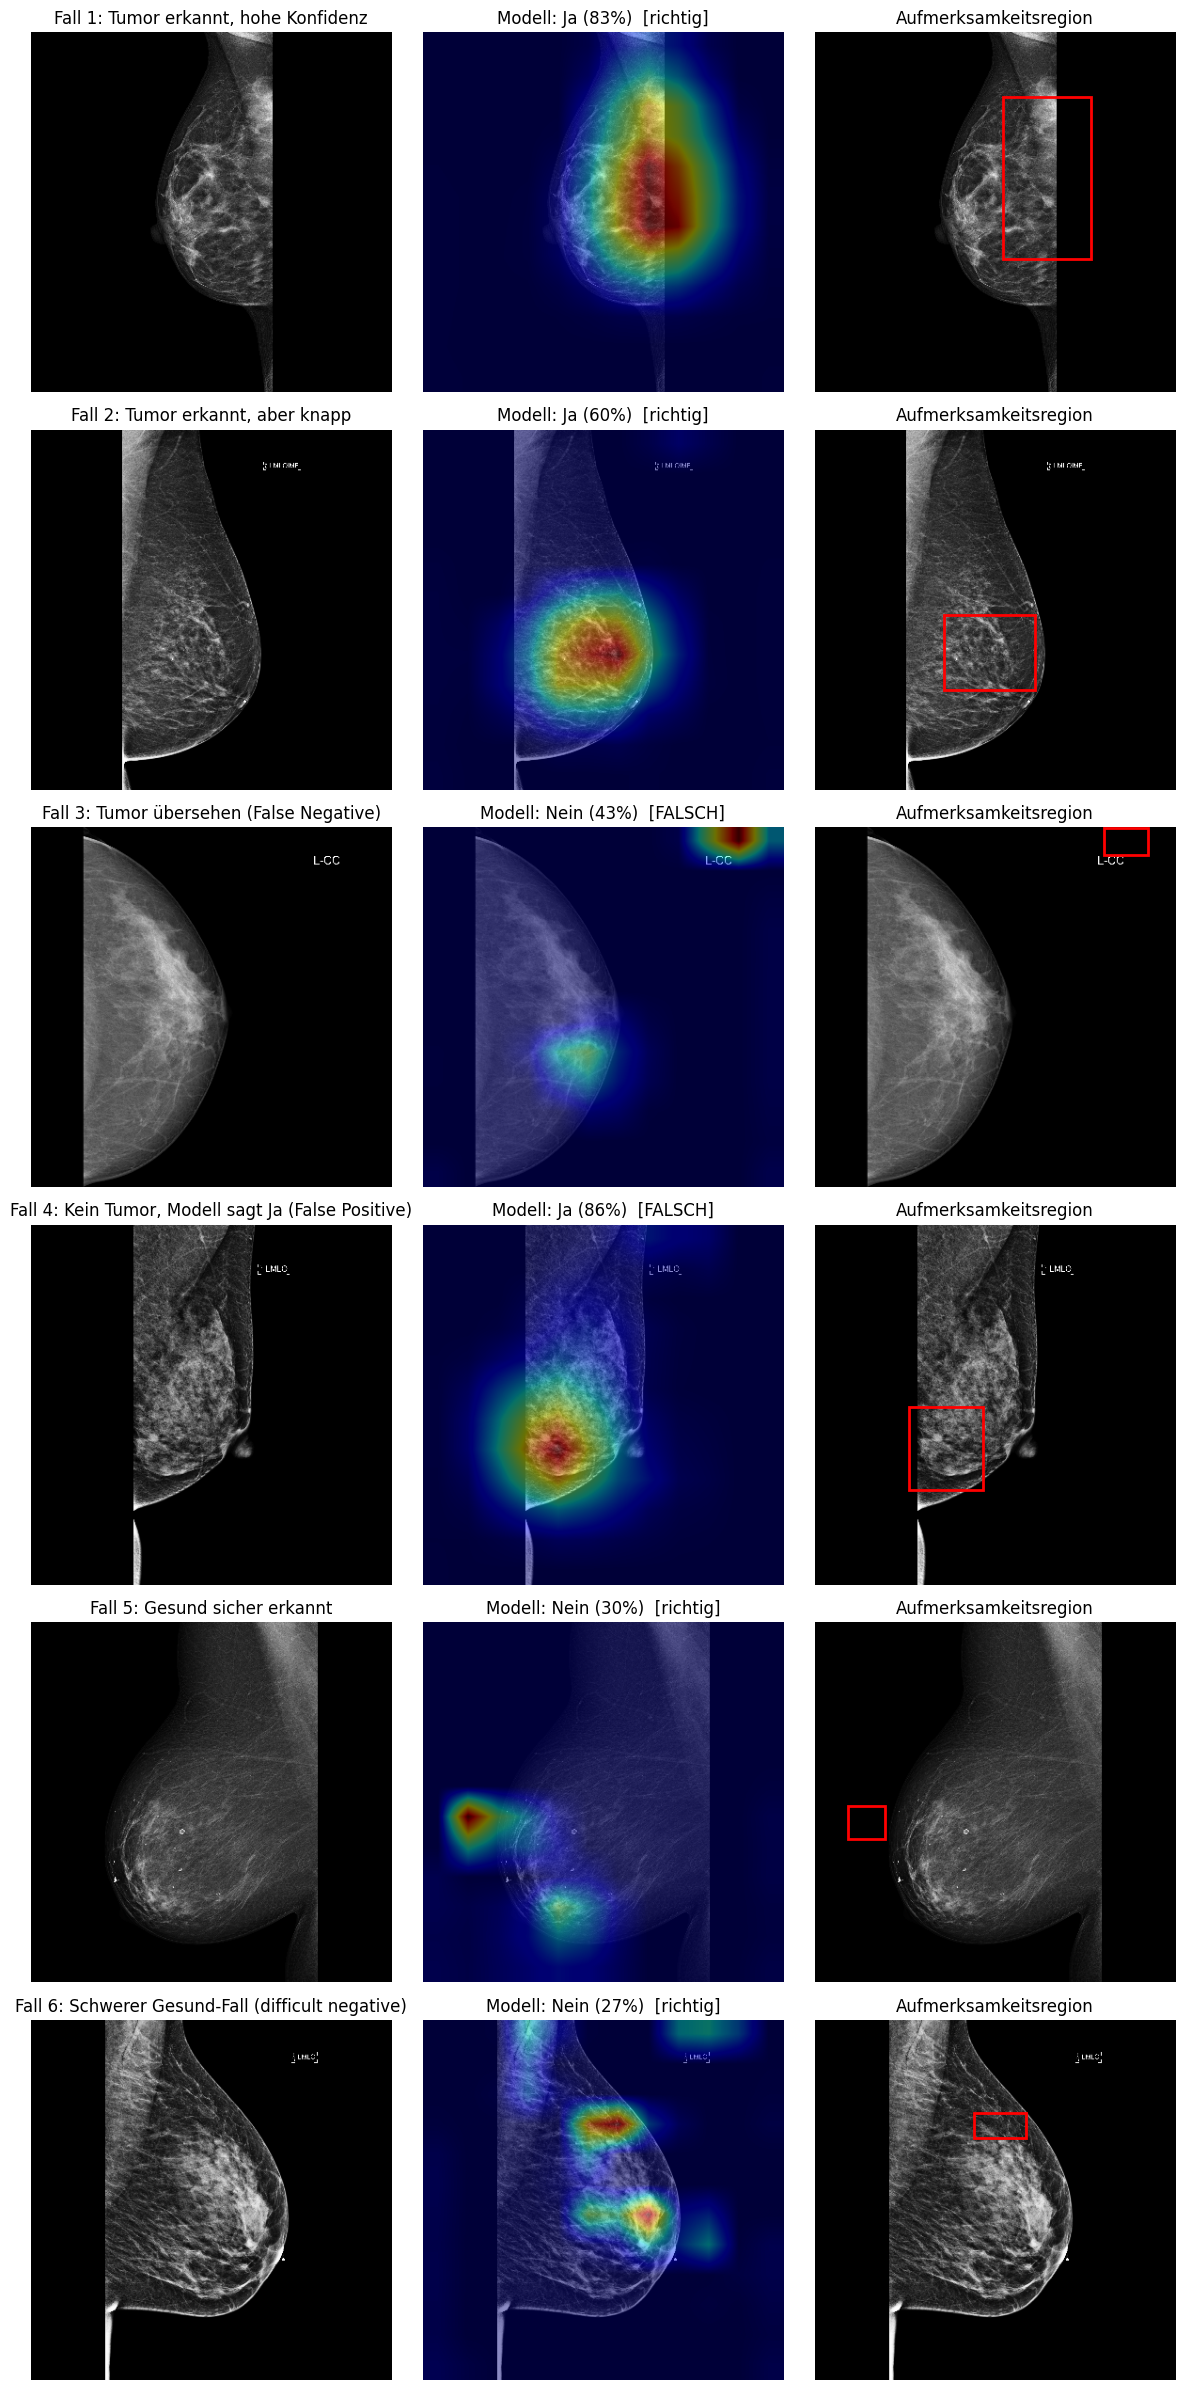

Hinweis: Die Heatmap und die markierte Region zeigen, welche Bildregionen
die Entscheidung des Modells am stärksten beeinflusst haben. Dies ist
KEINE validierte Tumor-Lokalisierung. Der RSNA-Datensatz enthält nur
Bild-Level-Labels (Krebs Ja/Nein), keine Positions-Annotationen, daher
kann kein Modell lernen, wo genau ein Tumor sitzt. Bei Fehlklassifikationen
kann die markierte Region zeigen, ob das Modell auf irrelevante
Bildregionen (z.B. Bildrand, Artefakte) statt auf Brustgewebe achtet.


In [50]:
# Grad-CAM: Heatmap der entscheidungsrelevanten Bildregionen

class GradCAM:
    """Erfasst Aktivierungen und Gradienten einer Zielschicht per Hook,
    um daraus eine Heatmap der entscheidungsrelevanten Regionen zu berechnen."""
    def __init__(self, modell, ziel_schicht):
        self.modell = modell
        self.aktivierungen = None
        self.gradienten = None
        ziel_schicht.register_forward_hook(self._forward_hook)
        ziel_schicht.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, modul, eingabe, ausgabe):
        self.aktivierungen = ausgabe.detach()

    def _backward_hook(self, modul, grad_eingabe, grad_ausgabe):
        self.gradienten = grad_ausgabe[0].detach()

    def erzeuge_heatmap(self, bild_tensor, zielgroesse):
        self.modell.eval()
        bild_tensor = bild_tensor.unsqueeze(0).to(DEVICE)
        bild_tensor.requires_grad_(True)
        logit = self.modell(bild_tensor)
        self.modell.zero_grad()
        logit.backward()

        gradienten   = self.gradienten[0]                     # (C, H, W)
        aktivierung  = self.aktivierungen[0]                  # (C, H, W)
        gewichte     = gradienten.mean(dim=(1, 2))            # (C,)

        cam = torch.zeros(aktivierung.shape[1:], dtype=torch.float32, device=DEVICE)
        for i, w in enumerate(gewichte):
            cam += w * aktivierung[i]
        cam = torch.relu(cam).cpu().numpy()
        cam = cv2.resize(cam, (zielgroesse, zielgroesse))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam


def entnormalisiere(bild_tensor):
    """Macht die ImageNet-Normalisierung rückgängig, für die Anzeige."""
    mean = torch.tensor(imagenet_mean).view(3, 1, 1)
    std  = torch.tensor(imagenet_std).view(3, 1, 1)
    bild = bild_tensor.cpu() * std + mean
    return bild.clamp(0, 1).permute(1, 2, 0).numpy()


def aufmerksamkeitsregion(heatmap, schwelle=0.6):
    """Findet die zusammenhängende Region mit der stärksten Aktivierung und
    gibt eine Bounding Box (x, y, w, h) zurück. Liefert None, wenn nichts über
    der Schwelle liegt. WICHTIG: das ist eine Modell-Aufmerksamkeitsregion,
    keine bestätigte Tumorposition (dafür fehlen im Datensatz Positions-Labels)."""
    maske = (heatmap >= schwelle).astype(np.uint8) * 255
    konturen, _ = cv2.findContours(maske, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not konturen:
        return None
    groesste = max(konturen, key=cv2.contourArea)
    return cv2.boundingRect(groesste)  # (x, y, w, h)


gradcam = GradCAM(modell_final, modell_final.layer4)

# Sechs verschiedene Fälle gezielt zeigen, damit die Grad-CAM-Analyse
# aussagekräftig ist: richtig erkannte Tumore, beide Fehlerarten und ein
# schwerer Trickfall. Gezogen wird zufällig aus Pools der jeweils klarsten
# Fälle, ein anderer Seed liefert also andere (aber weiterhin klare) Bilder.

SEED_BSP = 5          # andere Zahl gibt eine andere zufällige Auswahl
rng_bsp = np.random.RandomState(SEED_BSP)


def bsp_aus_val(idx, quelle):
    """Baut einen Beispiel-Eintrag aus einem Validierungs-Index."""
    zeile = ds_va_fin.df.iloc[idx]
    bild_tensor, _, _ = ds_va_fin[idx]
    return {
        'tensor':     bild_tensor,
        'label':      int(alle_labels[idx]),
        'quelle':     quelle,
        'patient_id': zeile['patient_id'],
        'image_id':   zeile['image_id'],
        'dnc':        zeile.get('difficult_negative_case', '?'),
    }


def sicherster_pool(indices, absteigend=True, mindestens=4, anteil=0.3):
    """Sortiert die Indizes nach der Tumor-Wahrscheinlichkeit und gibt die
    zuverlässigsten Fälle als Pool zurück. absteigend=True nimmt die höchste
    Wahrscheinlichkeit zuerst (sichere Tumore oder sichere Fehler),
    absteigend=False die niedrigste zuerst (sicher gesund)."""
    if len(indices) == 0:
        return indices
    sortiert = indices[np.argsort(alle_wahrsch[indices])]
    if absteigend:
        sortiert = sortiert[::-1]
    k = max(mindestens, int(len(sortiert) * anteil))
    return sortiert[:k]


beispiele = []
benutzt = set()


def waehle_aus(pool, quelle, anzahl=1):
    """Zieht bis zu 'anzahl' zufällige Bilder aus dem Pool und hängt sie an.
    Bereits gewählte Bilder werden übersprungen, damit nichts doppelt kommt.
    Ist der Pool leer, gibt es nur einen kurzen Hinweis."""
    frei = [int(i) for i in pool if int(i) not in benutzt]
    if not frei:
        print(f'Hinweis: kein Bild für "{quelle}" gefunden, wird übersprungen.')
        return
    for idx in rng_bsp.choice(frei, size=min(anzahl, len(frei)), replace=False):
        benutzt.add(int(idx))
        beispiele.append(bsp_aus_val(int(idx), quelle))


# Basismasken für die Fallauswahl
ist_tumor  = alle_labels == 1
ist_gesund = alle_labels == 0
sagt_ja    = alle_klassen == 1
sagt_nein  = alle_klassen == 0
if 'difficult_negative_case' in ds_va_fin.df.columns:
    ist_schwer_neg = ds_va_fin.df['difficult_negative_case'].fillna(False).astype(bool).values
else:
    ist_schwer_neg = np.zeros(len(alle_labels), dtype=bool)

# Fall 1: Tumor korrekt erkannt, hohe Konfidenz (Grad-CAM am klarsten)
waehle_aus(sicherster_pool(np.where(ist_tumor & sagt_ja)[0], absteigend=True),
           'Tumor erkannt, hohe Konfidenz')

# Fall 2: Tumor korrekt erkannt, aber nur knapp (niedrige Konfidenz)
waehle_aus(sicherster_pool(np.where(ist_tumor & sagt_ja)[0], absteigend=False),
           'Tumor erkannt, aber knapp')

# Fall 3: Tumor übersehen (False Negative), klinisch der gefährlichste Fehler
waehle_aus(np.where(ist_tumor & sagt_nein)[0],
           'Tumor übersehen (False Negative)')

# Fall 4: kein Tumor, Modell sagt trotzdem Ja (False Positive, einfacher Fall)
fp_pool = np.where(ist_gesund & sagt_ja & ~ist_schwer_neg)[0]
if len(fp_pool) == 0:
    fp_pool = np.where(ist_gesund & sagt_ja)[0]
waehle_aus(sicherster_pool(fp_pool, absteigend=True),
           'Kein Tumor, Modell sagt Ja (False Positive)')

# Fall 5: gesund sicher erkannt (Kontrast, niedrigste Tumor-Wahrscheinlichkeit)
waehle_aus(sicherster_pool(np.where(ist_gesund & sagt_nein)[0], absteigend=False),
           'Gesund sicher erkannt')

# Fall 6: schwerer Gesund-Fall (difficult negative), egal ob richtig oder falsch
waehle_aus(np.where(ist_gesund & ist_schwer_neg)[0],
           'Schwerer Gesund-Fall (difficult negative)')


# Darstellung: pro Beispiel drei Panels (Original, Grad-CAM, Region)
fig, achsen = plt.subplots(len(beispiele), 3, figsize=(12, 4 * len(beispiele)))
if len(beispiele) == 1:
    achsen = achsen.reshape(1, -1)

for reihe, bsp in enumerate(beispiele):
    bild_tensor = bsp['tensor']
    heatmap = gradcam.erzeuge_heatmap(bild_tensor, zielgroesse=bild_tensor.shape[-1])
    bild_original = entnormalisiere(bild_tensor)

    # Vorhersage on-the-fly (wie im Finalmodell: sigmoid auf den Logit)
    with torch.no_grad():
        wahrsch = torch.sigmoid(modell_final(bild_tensor.unsqueeze(0).to(DEVICE))).item()
    vorh_klasse = int(wahrsch >= 0.5)

    tats = 'Ja' if bsp['label'] == 1 else ('Nein' if bsp['label'] == 0 else '?')
    vorh = 'Ja' if vorh_klasse == 1 else 'Nein'
    if bsp['label'] in (0, 1):
        ok = 'richtig' if vorh_klasse == bsp['label'] else 'FALSCH'
    else:
        ok = 'Label unbekannt'
    # Werte für die nächste Zelle (ID-Ausgabe) merken
    bsp['vorh'], bsp['wahrsch'], bsp['ok'] = vorh, wahrsch, ok

    achsen[reihe, 0].imshow(bild_original)
    achsen[reihe, 0].set_title(f"Fall {reihe + 1}: {bsp['quelle']}")
    achsen[reihe, 0].axis('off')

    achsen[reihe, 1].imshow(bild_original)
    achsen[reihe, 1].imshow(heatmap, cmap='jet', alpha=0.45)
    achsen[reihe, 1].set_title(f'Modell: {vorh} ({wahrsch*100:.0f}%)  [{ok}]')
    achsen[reihe, 1].axis('off')

    box = aufmerksamkeitsregion(heatmap, schwelle=0.6)
    achsen[reihe, 2].imshow(bild_original)
    if box is not None:
        x, y, w, h = box
        rechteck = plt.Rectangle((x, y), w, h, fill=False, edgecolor='red', linewidth=2)
        achsen[reihe, 2].add_patch(rechteck)
        achsen[reihe, 2].set_title('Aufmerksamkeitsregion')
    else:
        achsen[reihe, 2].set_title('keine klare Region')
    achsen[reihe, 2].axis('off')

plt.tight_layout()
plt.show()

print('Hinweis: Die Heatmap und die markierte Region zeigen, welche Bildregionen')
print('die Entscheidung des Modells am stärksten beeinflusst haben. Dies ist')
print('KEINE validierte Tumor-Lokalisierung. Der RSNA-Datensatz enthält nur')
print('Bild-Level-Labels (Krebs Ja/Nein), keine Positions-Annotationen, daher')
print('kann kein Modell lernen, wo genau ein Tumor sitzt. Bei Fehlklassifikationen')
print('kann die markierte Region zeigen, ob das Modell auf irrelevante')
print('Bildregionen (z.B. Bildrand, Artefakte) statt auf Brustgewebe achtet.')

In [47]:
# Patient-/Bild-IDs und Metadaten für alle Grad-CAM-Beispielbilder
for reihe, bsp in enumerate(beispiele, start=1):
    tats = 'Ja' if bsp['label'] == 1 else ('Nein' if bsp['label'] == 0 else '?')
    print(f"Fall {reihe} [{bsp['quelle']}] | Patient {bsp['patient_id']}, "
          f"Bild {bsp['image_id']}: tatsächlich={tats}, "
          f"Modell sagt={bsp.get('vorh', '?')} [{bsp.get('ok', '?')}], "
          f"difficult_negative_case={bsp['dnc']}")

Fall 1 [Tumor erkannt, hohe Konfidenz] | Patient 60653, Bild 101263956: tatsächlich=Ja, Modell sagt=Ja [richtig], difficult_negative_case=False
Fall 2 [Tumor erkannt, aber knapp] | Patient 12153, Bild 1827516400: tatsächlich=Ja, Modell sagt=Ja [richtig], difficult_negative_case=False
Fall 3 [Tumor übersehen (False Negative)] | Patient 106, Bild 76321767: tatsächlich=Ja, Modell sagt=Nein [FALSCH], difficult_negative_case=False
Fall 4 [Kein Tumor, Modell sagt Ja (False Positive)] | Patient 37459, Bild 1058253048: tatsächlich=Nein, Modell sagt=Ja [FALSCH], difficult_negative_case=False
Fall 5 [Gesund sicher erkannt] | Patient 16668, Bild 93540989: tatsächlich=Nein, Modell sagt=Nein [richtig], difficult_negative_case=False
Fall 6 [Schwerer Gesund-Fall (difficult negative)] | Patient 38455, Bild 2019187214: tatsächlich=Nein, Modell sagt=Nein [richtig], difficult_negative_case=True


## 23. Test-Set-Evaluation - ehrliche Endbewertung (70/15/15)

Bisher wurde die beste Epoche auf der Validierung ausgewählt und die
Validierungs-AUC berichtet. Das ist optimistisch verzerrt. Hier wird das
beste Setup auf einem patientenweisen 70/15/15-Split neu trainiert und
genau einmal auf einem unberührten Test-Set ausgewertet.

Patientenweiser 3-Wege-Split (Seed 42), gesamt 836 Patienten:
  Train: 585 Patienten | 1604 Bilder | Krebs  789
  Val  : 125 Patienten |  372 Bilder | Krebs  203
  Test : 126 Patienten |  340 Bilder | Krebs  166
  Nachweis bestanden: keine Patienten- und keine Bild-Überschneidung.

Training auf 70 % (20 Epochen). Beste Epoche wird über Val
ausgewählt, das Test-Set bleibt dabei komplett unberührt:
  Epoche  1/20 | Train 0.7480 | Val-AUC 0.5207  *beste*
  Epoche  2/20 | Train 0.7186 | Val-AUC 0.5349  *beste*
  Epoche  3/20 | Train 0.7165 | Val-AUC 0.5470  *beste*
  Epoche  4/20 | Train 0.7135 | Val-AUC 0.5311
  Epoche  5/20 | Train 0.7116 | Val-AUC 0.5975  *beste*
  Epoche  6/20 | Train 0.7098 | Val-AUC 0.6099  *beste*
  Epoche  7/20 | Train 0.7022 | Val-AUC 0.5966
  Epoche  8/20 | Train 0.6962 | Val-AUC 0.5775
  Epoche  9/20 | Train 0.6943 | Val-AUC 0.6279  *beste*
  Epoche 10/20 | Train 0.6875 | Val-AUC 0.6775  *beste*
  Epoche 11/20 | Train 0.6907 | Val-AUC 0.6260
  Epoche 12/20 | Tra

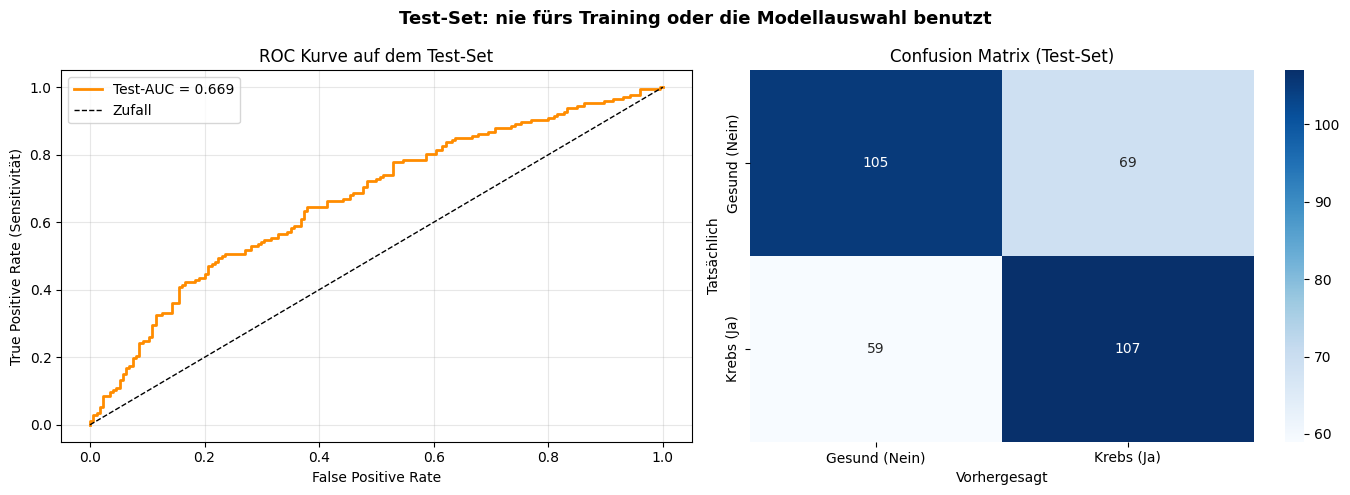

ERGEBNIS AUF DEM TEST-SET (einmalig, ohne Auswahl-Verzerrung):
  Test-AUC : 0.6685   95%-Bootstrap-KI [0.6091, 0.7269]
  Accuracy : 0.6235

              precision    recall  f1-score   support

      Gesund       0.64      0.60      0.62       174
       Krebs       0.61      0.64      0.63       166

    accuracy                           0.62       340
   macro avg       0.62      0.62      0.62       340
weighted avg       0.62      0.62      0.62       340

Val-AUC (zur Auswahl benutzt): 0.6915
Differenz Val minus Test    : +0.0230
Eine positive Differenz ist genau der erwartete Optimismus der
Validierung, weil die beste Epoche dort ausgesucht wurde. Die Test-AUC
ist die ehrliche Zahl und gehört als Kernergebnis in die Arbeit.


In [63]:
# Test-Set-Evaluation: ehrliche Endbewertung des besten Setups
#
# Warum diese Zelle:
# In allen bisherigen Läufen wurde die beste Epoche AUF der Validierung
# ausgewählt UND anschließend die Validierungs-AUC als Ergebnis berichtet.
# Wenn man aus 20 Epochen das Maximum auf demselben Datensatz zieht, auf dem
# man auch misst, ist der Wert systematisch zu optimistisch (Selection Bias).
# Die berichtete AUC ist dann eher eine Obergrenze als eine ehrliche Schätzung.
#
# Deshalb hier ein sauberer patientenweiser 70/15/15-Split:
#   Train (70 %) -> Modell lernen
#   Val   (15 %) -> beste Epoche auswählen
#   Test  (15 %) -> genau EINMAL ganz am Ende anfassen = die Berichtszahl
#
# WICHTIG: Es wird bewusst ein FRISCHES Modell trainiert. Die schon
# gespeicherten Gewichte (modell_final_beste.pth usw.) wurden auf 80 % ALLER
# Patienten trainiert und haben damit Patienten gesehen, die jetzt im Test-Set
# liegen. Diese Gewichte hier zu laden würde das Ergebnis wertlos machen.

TEST_SEED    = 42
ANTEIL_TRAIN = 0.70
ANTEIL_VAL   = 0.15    # Test bekommt den Rest (0.15)
TEST_EPOCHEN = 20
TEST_BATCH   = 8
TEST_LR      = 3e-4    # bestes Setup aus E4
TEST_PFAD    = 'modell_testsplit_beste.pth'

torch.manual_seed(TEST_SEED)
np.random.seed(TEST_SEED)

# 1) Patientenweiser 3-Wege-Split
patienten = df_verfuegbar['patient_id'].unique().copy()
rng_split = np.random.default_rng(TEST_SEED)
rng_split.shuffle(patienten)
n_pat = len(patienten)
n_tr  = int(n_pat * ANTEIL_TRAIN)
n_va  = int(n_pat * ANTEIL_VAL)
pat_train = set(patienten[:n_tr])
pat_val   = set(patienten[n_tr:n_tr + n_va])
pat_test  = set(patienten[n_tr + n_va:])

# 2) NACHWEIS gegen Data Leakage: kein Patient darf in zwei Mengen liegen.
#    Falls doch, bricht die Zelle hier mit einem Fehler ab. Diese Prüfung ist
#    der Beleg dafür, dass das Modell das Test-Set nie gesehen hat.
assert not (pat_train & pat_val),  'Überschneidung Train/Val!'
assert not (pat_train & pat_test), 'Überschneidung Train/Test!'
assert not (pat_val   & pat_test), 'Überschneidung Val/Test!'
assert len(pat_train) + len(pat_val) + len(pat_test) == n_pat

df_tr = df_verfuegbar[df_verfuegbar['patient_id'].isin(pat_train)]
df_va = df_verfuegbar[df_verfuegbar['patient_id'].isin(pat_val)]
df_te = df_verfuegbar[df_verfuegbar['patient_id'].isin(pat_test)]

# Zusätzlich auf Bildebene prüfen (kein einziges Bild doppelt)
assert not (set(df_tr['image_id']) & set(df_te['image_id'])), 'Bild in Train UND Test!'
assert not (set(df_va['image_id']) & set(df_te['image_id'])), 'Bild in Val UND Test!'

print(f'Patientenweiser 3-Wege-Split (Seed {TEST_SEED}), gesamt {n_pat} Patienten:')
print(f'  Train: {len(pat_train):>3} Patienten | {len(df_tr):>4} Bilder | Krebs {int((df_tr["cancer"]==1).sum()):>4}')
print(f'  Val  : {len(pat_val):>3} Patienten | {len(df_va):>4} Bilder | Krebs {int((df_va["cancer"]==1).sum()):>4}')
print(f'  Test : {len(pat_test):>3} Patienten | {len(df_te):>4} Bilder | Krebs {int((df_te["cancer"]==1).sum()):>4}')
print('  Nachweis bestanden: keine Patienten- und keine Bild-Überschneidung.')

# 3) DataLoader (Test bekommt val_transforms, also keine Augmentierung)
ds_tr_t = MammografieDataset(df_tr, BILDER_ORDNER, train_transforms_3kanal, fuer_resnet18=True)
ds_va_t = MammografieDataset(df_va, BILDER_ORDNER, val_transforms_3kanal,   fuer_resnet18=True)
ds_te_t = MammografieDataset(df_te, BILDER_ORDNER, val_transforms_3kanal,   fuer_resnet18=True)
ld_tr_t = DataLoader(ds_tr_t, batch_size=TEST_BATCH, shuffle=True,  num_workers=0, pin_memory=torch.cuda.is_available())
ld_va_t = DataLoader(ds_va_t, batch_size=TEST_BATCH, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
ld_te_t = DataLoader(ds_te_t, batch_size=TEST_BATCH, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

# 4) Frisches Modell im besten Setup (layer3 + layer4 aufgetaut, pos_weight)
npos_t = int((df_tr['cancer'] == 1).sum())
nneg_t = int((df_tr['cancer'] == 0).sum())
pw_t = torch.tensor([nneg_t / npos_t], dtype=torch.float32, device=DEVICE)

modell_test = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for p in modell_test.parameters():
    p.requires_grad = False
for p in modell_test.layer3.parameters():
    p.requires_grad = True
for p in modell_test.layer4.parameters():
    p.requires_grad = True
modell_test.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(modell_test.fc.in_features, 1))
modell_test = modell_test.to(DEVICE)

krit_t  = nn.BCEWithLogitsLoss(pos_weight=pw_t)
opt_t   = optim.Adam(filter(lambda p: p.requires_grad, modell_test.parameters()),
                     lr=TEST_LR, weight_decay=1e-4)
sched_t = optim.lr_scheduler.ReduceLROnPlateau(opt_t, mode='max', factor=0.5, patience=4)

beste_val_auc_t = 0.0
print(f'\nTraining auf 70 % ({TEST_EPOCHEN} Epochen). Beste Epoche wird über Val')
print('ausgewählt, das Test-Set bleibt dabei komplett unberührt:')
for ep in range(TEST_EPOCHEN):
    tl = trainiere_eine_epoche(modell_test, ld_tr_t, opt_t, krit_t)
    _, labs_v_t, preds_v_t = validiere(modell_test, ld_va_t, krit_t)
    fpr_v, tpr_v, _ = roc_curve(labs_v_t, preds_v_t)
    a_val = auc(fpr_v, tpr_v)
    sched_t.step(a_val)
    if a_val > beste_val_auc_t:
        beste_val_auc_t = a_val
        torch.save(modell_test.state_dict(), TEST_PFAD)
        marker = '  *beste*'
    else:
        marker = ''
    print(f'  Epoche {ep+1:>2}/{TEST_EPOCHEN} | Train {tl:.4f} | Val-AUC {a_val:.4f}{marker}', flush=True)

print(f'\nBeste Val-AUC (nur zur Modellauswahl benutzt): {beste_val_auc_t:.4f}')

# 5) JETZT ERST das Test-Set anfassen, genau einmal, mit dem über Val gewählten Modell
modell_test.load_state_dict(torch.load(TEST_PFAD, map_location=DEVICE, weights_only=True))
modell_test.eval()

test_labels, test_wahrsch = [], []
with torch.no_grad():
    for bilder, labels, meta in ld_te_t:
        logits = modell_test(bilder.to(DEVICE))
        test_wahrsch.extend(torch.sigmoid(logits).cpu().numpy().flatten())
        test_labels.extend(labels.numpy())

test_labels  = np.array(test_labels)
test_wahrsch = np.array(test_wahrsch)
test_klassen = (test_wahrsch >= 0.5).astype(int)

fpr_t, tpr_t, _ = roc_curve(test_labels, test_wahrsch)
test_auc = auc(fpr_t, tpr_t)

# Bootstrap-Konfidenzintervall: die Test-AUC steht auf einem einzelnen,
# begrenzten Datensatz. Das Intervall zeigt, wie genau die Zahl überhaupt ist.
rng_boot = np.random.default_rng(0)
boot = []
for _ in range(2000):
    idx = rng_boot.integers(0, len(test_labels), len(test_labels))
    if len(np.unique(test_labels[idx])) < 2:
        continue
    f_b, t_b, _ = roc_curve(test_labels[idx], test_wahrsch[idx])
    boot.append(auc(f_b, t_b))
test_ci_lo, test_ci_hi = np.percentile(boot, [2.5, 97.5])

# 6) Darstellung
cm_t = confusion_matrix(test_labels, test_klassen)
fig, achsen = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Test-Set: nie fürs Training oder die Modellauswahl benutzt',
             fontsize=13, fontweight='bold')

achsen[0].plot(fpr_t, tpr_t, color='darkorange', lw=2, label=f'Test-AUC = {test_auc:.3f}')
achsen[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Zufall')
achsen[0].set_xlabel('False Positive Rate')
achsen[0].set_ylabel('True Positive Rate (Sensitivität)')
achsen[0].set_title('ROC Kurve auf dem Test-Set')
achsen[0].legend(); achsen[0].grid(alpha=0.3)

sns.heatmap(cm_t, annot=True, fmt='d', cmap='Blues', ax=achsen[1],
            xticklabels=['Gesund (Nein)', 'Krebs (Ja)'],
            yticklabels=['Gesund (Nein)', 'Krebs (Ja)'])
achsen[1].set_xlabel('Vorhergesagt')
achsen[1].set_ylabel('Tatsächlich')
achsen[1].set_title('Confusion Matrix (Test-Set)')

plt.tight_layout(); plt.show()

print('ERGEBNIS AUF DEM TEST-SET (einmalig, ohne Auswahl-Verzerrung):')
print(f'  Test-AUC : {test_auc:.4f}   95%-Bootstrap-KI [{test_ci_lo:.4f}, {test_ci_hi:.4f}]')
print(f'  Accuracy : {(test_klassen == test_labels).mean():.4f}')
print()
print(classification_report(test_labels, test_klassen,
                            target_names=['Gesund', 'Krebs'], zero_division=0))
print(f'Val-AUC (zur Auswahl benutzt): {beste_val_auc_t:.4f}')
print(f'Differenz Val minus Test    : {beste_val_auc_t - test_auc:+.4f}')
print('Eine positive Differenz ist genau der erwartete Optimismus der')
print('Validierung, weil die beste Epoche dort ausgesucht wurde. Die Test-AUC')
print('ist die ehrliche Zahl und gehört als Kernergebnis in die Arbeit.')

In [70]:
# ABSCHLUSS: vollständige Ergebnisdokumentation speichern.
# (Modelle A/B/C, E0-E7, E3-Absicherung, Finalmodell). Erst dann enthält die
# gespeicherte Doku auch die Kernzahl der Arbeit (Finalmodell layer3+4).
_ = speichere_ergebnisdoku()

Doku gespeichert:
  results\ergebnisse_20260716_1402.md
  results\ergebnisse_20260716_1402.csv
  results\verlaeufe_20260716_1402.csv
  (21 Kennzahlen erfasst)
